**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold,GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
from sklearn.metrics import classification_report, mean_squared_error, r2_score


**Load Dataset**

In [2]:
df = pd.read_csv('/content/bodyPerformance.csv')



**Dataset Overview**

**Number Of Rows**

In [3]:
print(f"Number of rows: {df.shape[0]}")

Number of rows: 13393


**Number Of Columns**

In [4]:
print(f"Number of columns: {df.shape[1]}")

Number of columns: 12


**Displaying Sample Rows**

In [5]:
print("\nSample Rows:")
display(df.sample(5))


Sample Rows:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
8413,30.0,M,175.0,64.7,29.5,92.0,136.0,27.5,-3.4,32.0,196.0,D
10955,29.0,F,164.7,53.9,24.1,66.0,117.0,20.6,7.5,12.0,154.0,D
11487,41.0,F,157.8,82.1,46.1,66.0,110.0,31.3,5.4,19.0,126.0,D
8083,61.0,F,166.1,57.6,30.0,52.0,120.0,25.8,20.3,12.0,117.0,C
12436,60.0,M,168.0,62.6,20.4,72.0,109.0,37.4,6.0,32.0,159.0,C


**column names**

In [6]:
print(f"Column names: {list(df.columns)}")

Column names: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm', 'class']


This dataset contains objective measurements of individuals, including body composition (height, weight, body fat), cardiovascular health (blood pressure), and physical strength/flexibility tests (grip force, sit-ups, jump distance). The main objective is to predict the class variable, which labels the physical performance into four categories (A, B, C, D), where A indicates top-tier fitness and D indicates the lowest level.

**Column Understanding**

The following table provides a detailed description of each feature in the dataset, including its meaning, data type, and logical constraints:



| Column Name | Meaning | Data Type | Constraints / Validation Rules |
| :--- | :--- | :--- | :--- |
| **age** | Age of the participant | Numeric (Integer) | Positive value (typically 20-64) |
| **gender** | Gender of the participant | Categorical | Must be 'M' (Male) or 'F' (Female) |
| **height_cm** | Height of the participant in cm | Numeric (Float) | Positive value |
| **weight_kg** | Weight of the participant in kg | Numeric (Float) | Positive value |
| **body fat_%** | Body fat percentage | Numeric (Float) | Positive percentage value |
| **diastolic** | Diastolic blood pressure (min) | Numeric (Float) | Positive value |
| **systolic** | Systolic blood pressure (max) | Numeric (Float) | Positive value |
| **gripForce** | Hand grip strength | Numeric (Float) | Positive value |
| **sit and bend forward_cm** | Flexibility measurement | Numeric (Float) | Can be positive or negative |
| **sit-ups counts** | Number of sit-ups performed | Numeric (Integer) | Positive integer or zero |
| **broad jump_cm** | Standing long jump distance in cm | Numeric (Float) | Positive value |
| **class** | Fitness performance category | Categorical | Ordinal: A (Best) to D (Lowest) |

 **Data Type Verification**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [8]:
print(df.dtypes)

age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object


**check unique**

In [9]:
df.nunique().sort_values(ascending=False)

,0
weight_kg,1398
gripForce,550
sit and bend forward_cm,528
body fat_%,527
height_cm,467
broad jump_cm,245
systolic,102
diastolic,89
sit-ups counts,81
age,44


In [10]:
# Show unique values in the 'gender' column
print(df['gender'].unique())

['M' 'F']


In [11]:
# coveting gender to binary type
df['gender'] = df['gender'].replace({
    'F': 0,
    'M': 1
})

df['gender'] = df['gender'].astype('int64')



In [12]:
# convert type of data
df['class'] = df['class'].astype('category')

In [13]:
df['sit-ups counts'] = df['sit-ups counts'].astype('int')
df['diastolic'] = df['diastolic'].astype('int')
df['systolic'] = df['systolic'].astype('int')

In [14]:
print(df.dtypes)

age                         float64
gender                        int64
height_cm                   float64
weight_kg                   float64
body fat_%                  float64
diastolic                     int64
systolic                      int64
gripForce                   float64
sit and bend forward_cm     float64
sit-ups counts                int64
broad jump_cm               float64
class                      category
dtype: object


**Data Type Corrections**

| Column | Original Type | New Type | Reason |
|------|------|------|------|
| gender | object | int64 | The gender column was encoded to numeric values (Female/F = 0, Male/M = 1) to make the variable suitable for statistical analysis and machine learning models that require numeric input. |
| class | object | category | The class column represents categorical fitness levels, so it was converted to category to improve memory efficiency and facilitate categorical analysis. |
| age | float / object | int64 | Age represents whole-number values, so it was converted to integer type. |
| diastolic | float | int64 | Blood pressure measurements are typically recorded as whole numbers. |
| systolic | float | int64 | Blood pressure measurements are typically recorded as whole numbers. |
| sit-ups counts | float | int64 | This variable represents the number of repetitions, which must be stored as an integer. |
| height_cm | float64 | float64 | Height is a continuous measurement that may contain decimal values. |
| weight_kg | float64 | float64 | Weight is a continuous measurement that may contain decimal values. |
| body fat_% | float64 | float64 | Body fat percentage is a continuous variable. |
| gripForce | float64 | float64 | Grip strength is a measured value that may include decimals. |
| sit and bend forward_cm | float64 | float64 | Flexibility measurement may include decimal values. |
| broad jump_cm | float64 | float64 | Jump distance is a continuous measurement. |

**Missing Values Analysis**

In [15]:
df.isna().sum()

,0
age,0
gender,0
height_cm,0
weight_kg,0
body fat_%,0
diastolic,0
systolic,0
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0


 **Data has no missing value**  

 **Duplicate Detection**

In [16]:
dupes = df.duplicated().sum()
if dupes > 0:
    print(f"Found {dupes} duplicate rows ({dupes/len(df)*100}%).")
    df = df.drop_duplicates()
else:
    print("No exact duplicates found.")


Found 1 duplicate rows (0.007466587023071754%).


 **Data Validity Checks**

In [17]:
print("=== 1. Detecting Violations ===")

invalid_weights = df[df['weight_kg'] < 0]
print(f"- Negative weights found: {len(invalid_weights)}")

invalid_ages = df[(df['age'] < 10) | (df['age'] > 100)]
print(f"- Unrealistic ages found: {len(invalid_ages)}")

invalid_bodyfat = df[(df['body fat_%']<3)|(df['body fat_%']>60)]
print(f"- Unrealistic body fat ratio found: {len(invalid_bodyfat)}")

invalid_flexibility = df[
    (df['sit and bend forward_cm'] < -30) |
    (df['sit and bend forward_cm'] > 60)]
print(f"- Unrealistic flexibility  found: {len(invalid_flexibility)}")

abnormal_bp = df[
    (df['systolic'] <= df['diastolic']) |
    (df['systolic'] < 50) |
    (df['diastolic'] < 30)]
print(f"- Abnormal blood pressure readings found: {len(abnormal_bp)}")

if len(abnormal_bp) > 0:
    print("\nSample of Abnormal Blood Pressure rows:")
    print(abnormal_bp[['age', 'gender', 'systolic', 'diastolic']])

if len(invalid_bodyfat) > 0:
    print(invalid_bodyfat[['age', 'gender', 'systolic', 'diastolic', 'body fat_%']])


if len(invalid_flexibility) > 0:
    print(invalid_flexibility[['age', 'gender', 'systolic', 'diastolic', 'body fat_%', 'sit and bend forward_cm']])




=== 1. Detecting Violations ===
- Negative weights found: 0
- Unrealistic ages found: 0
- Unrealistic body fat ratio found: 1
- Unrealistic flexibility  found: 2
- Abnormal blood pressure readings found: 7

Sample of Abnormal Blood Pressure rows:
        age  gender  systolic  diastolic
336    35.0       1       122          8
3524   44.0       1       145          6
7495   30.0       0       104        156
7597   30.0       1        14         67
8217   31.0       1        43         46
10624  26.0       0         0          0
12949  24.0       1        95         99
      age  gender  systolic  diastolic  body fat_%
735  21.0       1       122         69        78.4
       age  gender  systolic  diastolic  body fat_%  sit and bend forward_cm
2657  33.0       1       127         81        17.8                    213.0
3355  45.0       1       142         96        24.3                    185.0


In [18]:
print("\n=== 2. Handling Violations ===")
print(f"\nOriginal dataset size: {len(df)}")
print("Action taken: Dropping rows with abnormal blood pressure due to clear data entry errors.")

df = df[
    (df['systolic'] > df['diastolic']) &
    (df['systolic'] >= 50) &
    (df['diastolic'] >= 30)
]


print(f"Cleaned dataset size: {len(df)}")



=== 2. Handling Violations ===

Original dataset size: 13392
Action taken: Dropping rows with abnormal blood pressure due to clear data entry errors.
Cleaned dataset size: 13385


**Univariate Analysis**

In [19]:
# Calculate basic descriptive statistics
univariate_stats = df.describe().T  # Transpose the table for better readability

# Add Median and Skewness to the statistics table
univariate_stats['median'] = df.median(numeric_only=True)
univariate_stats['skewness'] = df.skew(numeric_only=True)

# Select and order only the required columns for the report
required_stats = univariate_stats[['mean', 'median', 'std', 'min', 'max', 'skewness']]

# Display the final summary table
print("Univariate Analysis Summary:")
print(required_stats)

Univariate Analysis Summary:
                               mean  median        std    min    max  skewness
age                       36.778633    32.0  13.628188   21.0   64.0  0.599280
gender                     0.632200     1.0   0.482225    0.0    1.0 -0.548375
height_cm                168.560620   169.2   8.426762  125.0  193.8 -0.186919
weight_kg                 67.446803    67.4  11.949858   26.3  138.1  0.350279
body fat_%                23.239786    22.8   7.257710    3.0   78.4  0.361284
diastolic                 78.810086    79.0  10.660758   30.0  126.0 -0.118134
systolic                 130.267090   130.0  14.611072   77.0  201.0  0.053103
gripForce                 36.962728    37.9  10.624118    0.0   70.5  0.018717
sit and bend forward_cm   15.208019    16.2   8.458296  -25.0  213.0  0.785741
sit-ups counts            39.767277    41.0  14.278049    0.0   80.0 -0.467435
broad jump_cm            190.129182   193.0  39.872018    0.0  303.0 -0.422499


**Univariate Analysis Interpretation1**.

 AgeInterpretation: The Mean ($36.77$) is higher than the Median ($32.0$), and the Skewness is $0.599$
.

**1.Distribution:** This indicates a Moderately Right-Skewed distribution This means the dataset contains more younger participants, but a few older individuals are pulling the average up.

**2. Physical Measurements (Height, Weight, Body Fat)Height:** The Mean ($168.56$) and Median ($169.2$) are very close, with a low skewness ($-0.187$). This suggests a Normal (Symmetric) Distribution.Weight & Body Fat: Both show low positive skewness ($0.34$ and $0.36$), meaning they are relatively balanced but lean slightly toward higher values.

**3. Blood Pressure (Diastolic & Systolic)Critical Observation:** Both columns have a Minimum value of $0.0$.**Data Quality Issue:** Physiologically, a blood pressure of $0$ is impossible for a living participant This indicates missing or corrupted data that must be handled in the preprocessing phase.

**4. Distribution:** Excluding the zeros, the distributions are nearly symmetric (Skewness near $0$).4. Performance Tests (GripForce, Sit-ups, Broad Jump)GripForce: Very symmetric (Skewness $0.01$), but also shows a minimum of $0.0$, which is likely a recording error.Sit-ups & Broad Jump: Both show Negative Skewness ($-0.46$ and $-0.42$) This means most participants performed relatively well, with a "tail" of participants who had much lower scores.

**5. Sit and Bend Forward (Flexibility)Interpretation:** This variable has the highest Skewness ($0.78$).

**Anomalies:** The range is extreme, from $-25$ to $213$. While negative values are possible in this specific flexibility test, a maximum of $213$ cm is highly unrealistic (over 2 meters of reach!) and should be investigated as a potential outlier.

**Distribution Analysis**

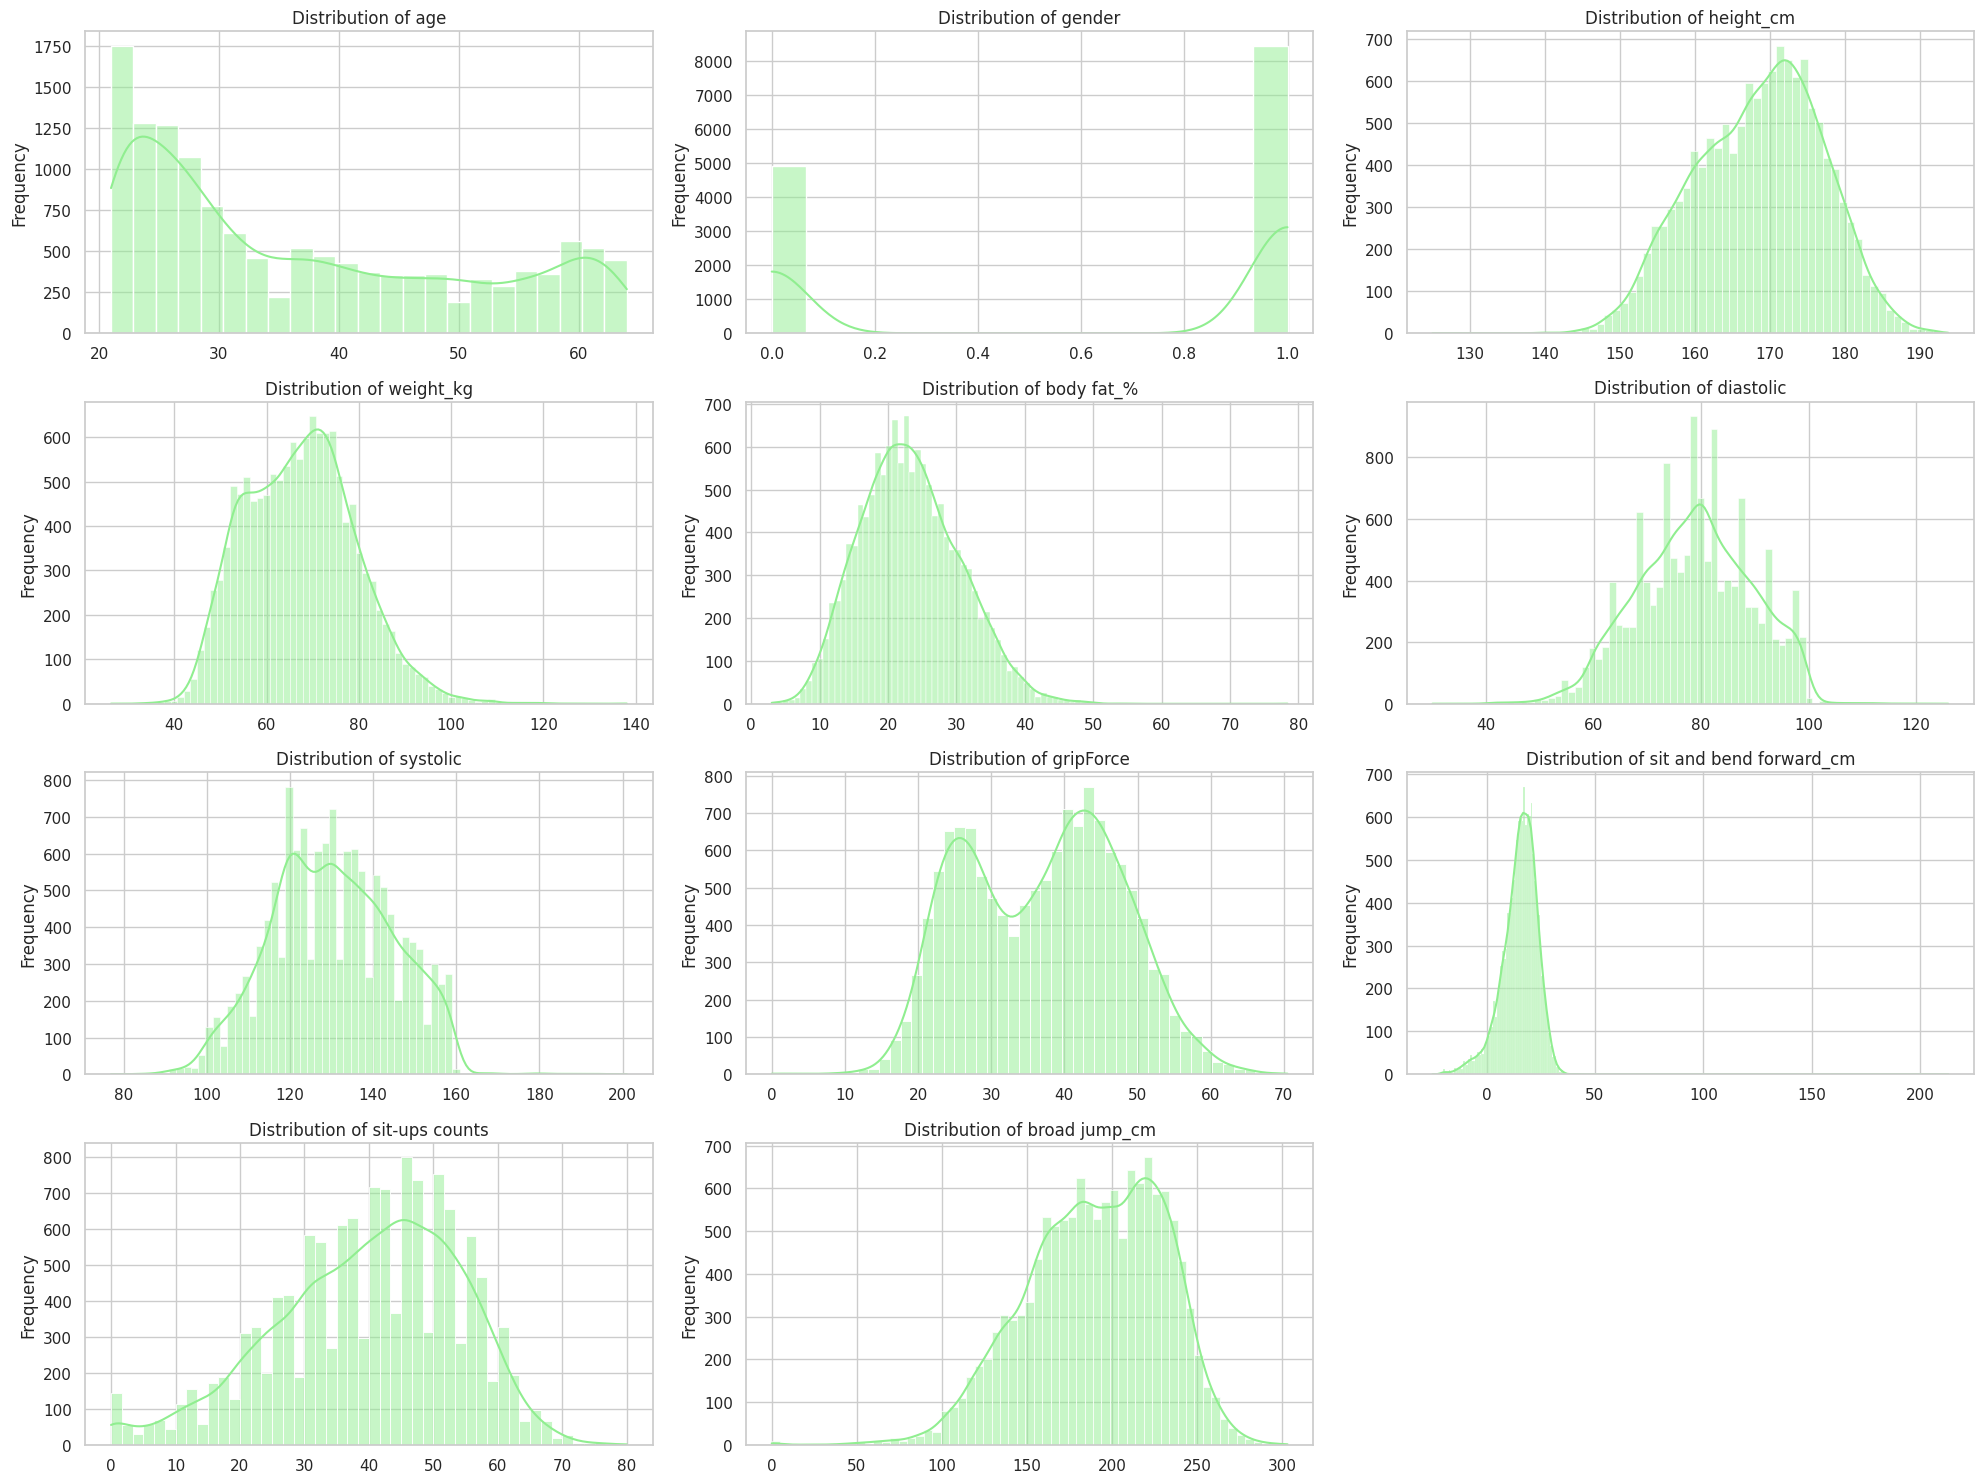

In [20]:

# Set the visual style
sns.set_theme(style="whitegrid")

# Select numeric columns (excluding categorical if needed)
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Create a grid of histograms
plt.figure(figsize=(20, 15))
for i, col in enumerate(numeric_columns):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, color='lightgreen') # kde=True adds the density curve
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Height Distribution:** "The distribution is roughly Normal (Symmetrical), centered around 168 cm This indicates a balanced representation of different heights

**Age Distribution:** The data is Positively Skewed A higher frequency of participants is in the 20-40 age range, with fewer participants as age increases Blood Pressure (Systolic/Diastolic)The distribution shows a Bimodal trend or an Anomaly at $0$ These $0$ values are unrealistic and represent data quality issues.

**Broad Jump:** This variable is Negatively Skewed, suggesting that the majority of participants performed well, with only a few outliers having very low jumping distances

**Outlier Detection**

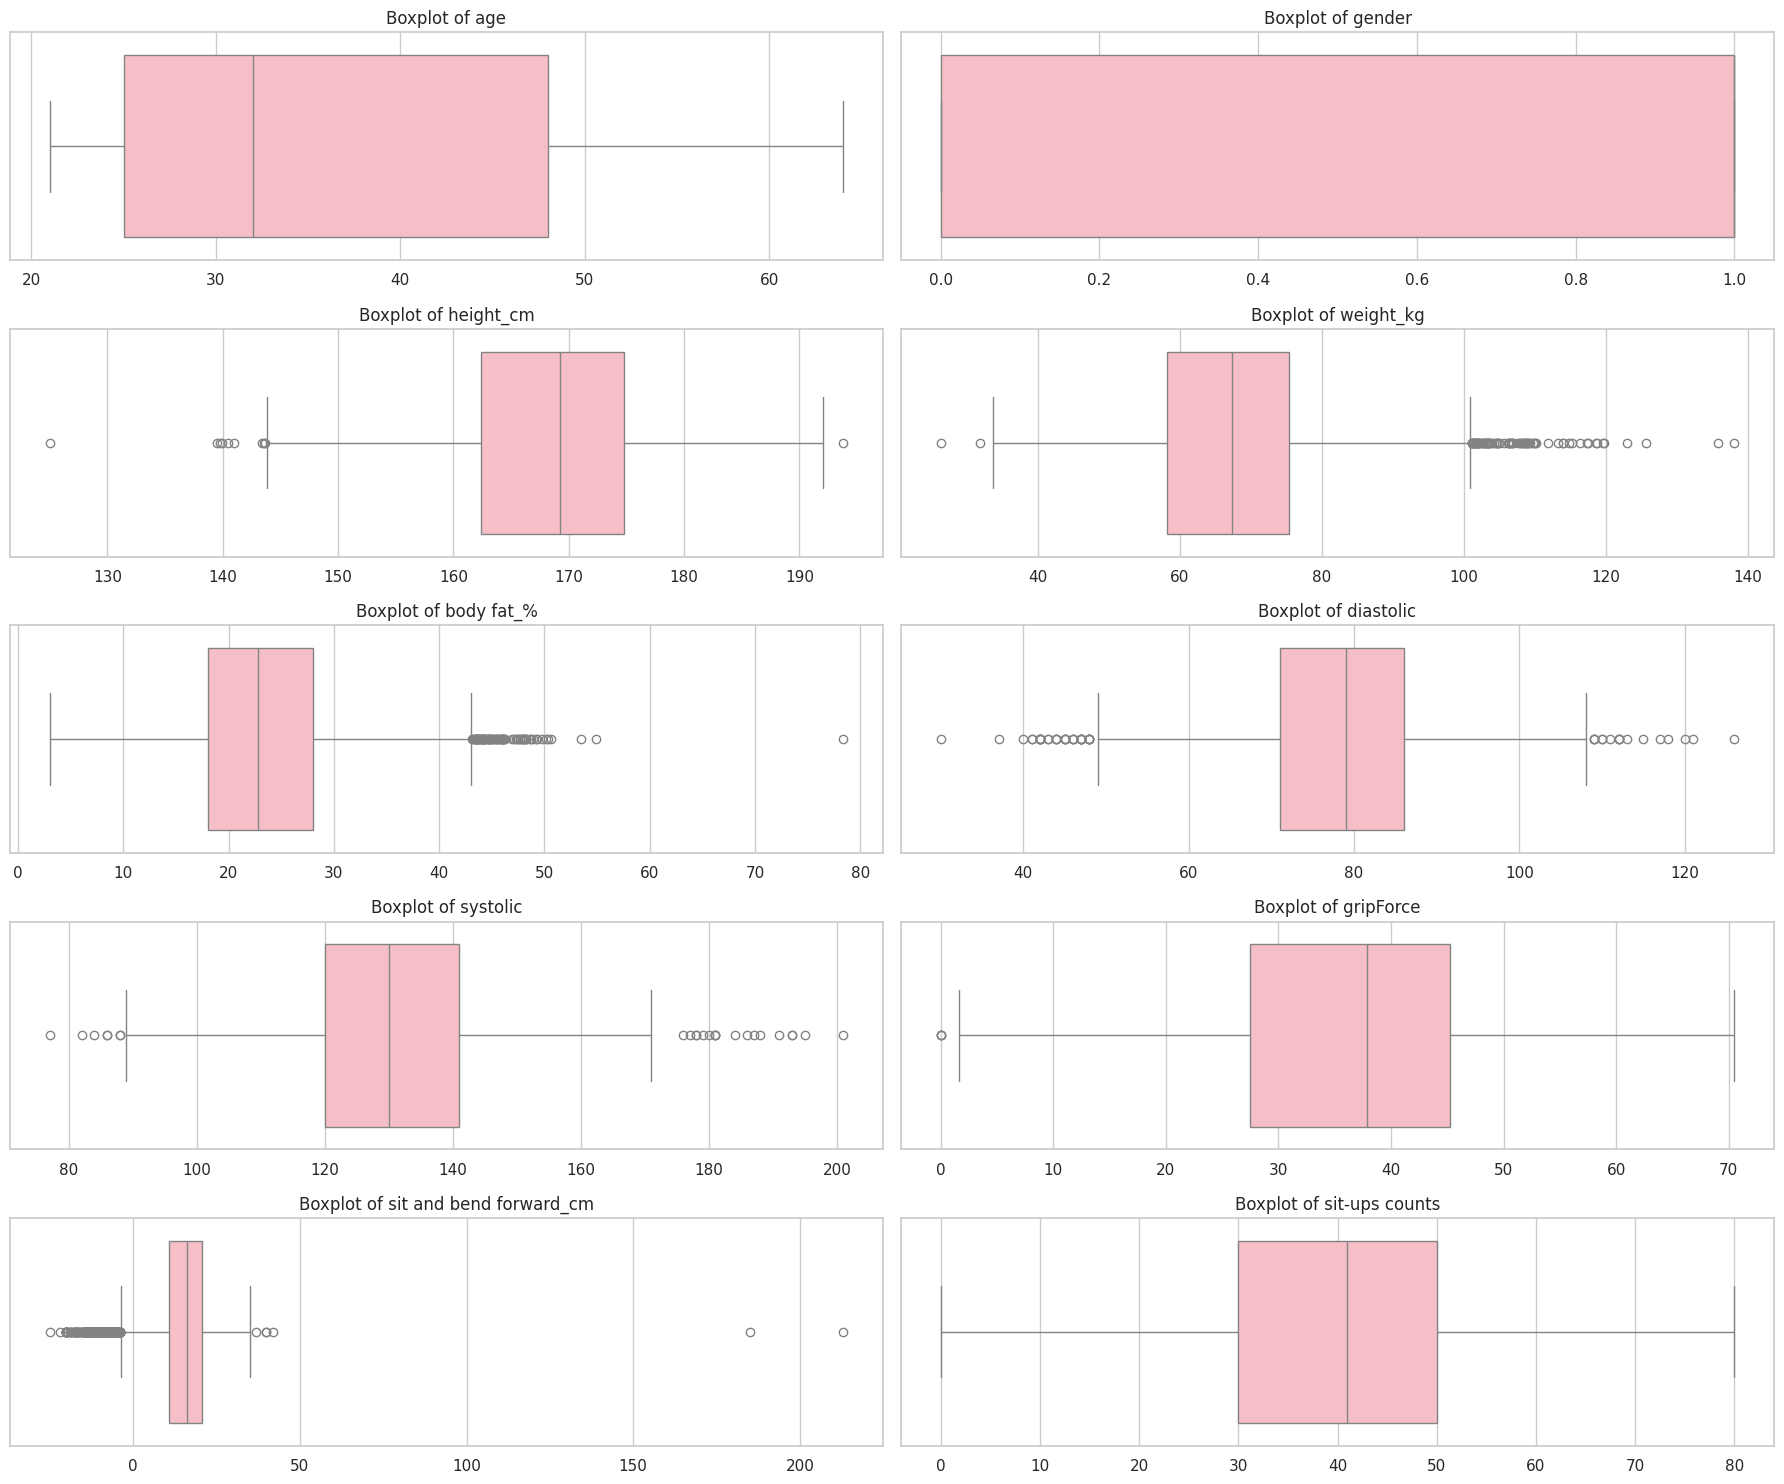

In [21]:
# 1. Select only numerical columns
num_cols = df.select_dtypes(include=['number']).columns

# 2. Setup the grid (5 rows x 2 columns)
fig, axes = plt.subplots(5, 2, figsize=(18, 15))
axes = axes.ravel() # Flatten the 2D array of axes into a 1D list for easy looping

# 3. Loop through the first 10 numerical columns and plot them
for i, col in enumerate(num_cols[:10]):
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightpink') # Set color to light pink
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('') # Optional: Clear x-label to reduce clutter

# 4. Final layout adjustments
plt.tight_layout()
plt.show()

1. The dataset includes heights ranging from 120 cm  to 200 cm : These values are statistically extreme but physically possible. They represent a diverse population including very short and very tall individuals.

2. Weight Analysis (Remove Data)
Observation: There are several records with weights below 40 kg.these values are unrealistic.
Action: Remove all records where weight is less than 40 kg to ensure data integrity.

3. Insights from Blood Pressure
Systolic/Diastolic at 0: These are physiologically impossible for a living person. These are likely missing values that were recorded as zero.
Action: Delete rows where systolic or diastolic pressure is 0.
Values where Diastolic is above 100 and Systolic is above 140 are identified as outliers in the boxplots. However, these are not data errors. These points represent individuals with Stage 2 Hypertension or Hypertensive Crisis.

4. Broad Jump:have a cluster of "low outliers" (some near 0 cm).
mea broad jump is likely a failed test or a recording error.
Action: Filter out extremely low values (e.g., jumps < 50 cm) if they appear to be errors rather than just low fitness.

5. Body Fat % (up to 78%): While very high, this is physically possible in clinical obesity settings

In [22]:
# Detecting Outliers using the Interquartile Range (IQR)
print("Summary of Outliers Detected:")
numeric_cols = df.select_dtypes(include=['number']).columns
for column in numeric_cols:
    # Calculating statistical boundaries
    lower_q = df[column].quantile(0.25)
    upper_q = df[column].quantile(0.75)
    iqr_val = upper_q - lower_q

    # Defining thresholds for anomalies
    lower_bound = lower_q - 1.5 * iqr_val
    upper_bound = upper_q + 1.5 * iqr_val

    # Filtering the data for outliers
    bad_data = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Calculating the impact percentage
    percentage = (len(bad_data) / len(df)) * 100

    # Clean output formatting
    print(f"Variable: {column:20} | Count: {len(bad_data):5} | Ratio: {percentage:.2f}%")

Summary of Outliers Detected:
Variable: age                  | Count:     0 | Ratio: 0.00%
Variable: gender               | Count:     0 | Ratio: 0.00%
Variable: height_cm            | Count:    10 | Ratio: 0.07%
Variable: weight_kg            | Count:    83 | Ratio: 0.62%
Variable: body fat_%           | Count:    77 | Ratio: 0.58%
Variable: diastolic            | Count:    49 | Ratio: 0.37%
Variable: systolic             | Count:    25 | Ratio: 0.19%
Variable: gripForce            | Count:     3 | Ratio: 0.02%
Variable: sit and bend forward_cm | Count:   409 | Ratio: 3.06%
Variable: sit-ups counts       | Count:     0 | Ratio: 0.00%
Variable: broad jump_cm        | Count:    57 | Ratio: 0.43%


The data is generally clean, with only sit and bend forward showing very minor adjustments needed.

In [23]:
# 1. Clean Blood Pressure (Remove impossible zero values)
df = df[(df['diastolic'].between(40,130)) & (df['systolic'].between(85,165))]

In [24]:
# 2. Clean Weight (Keep only 40kg and above)
df = df[df['weight_kg'] >= 40]

In [25]:
# 3. Clean Sit and Bend (Remove errors above 100cm)
df = df[df['sit and bend forward_cm'].between(-20,150)]

In [26]:
# 4. Clean Broad Jump (Remove values below 50cm)
df = df[df['broad jump_cm'] > 50]

In [27]:
# 5. Clean Grip Force (Remove 0 values)
#Extremely low values (like 0 or 10 cm) are treated as failed tests or data entry errors, rather than actual athletic performance.
df = df[df['gripForce'] > 0]

In [28]:
# 6. Clean fat (Keep only to 51)
df = df[df['body fat_%']<51]

In [29]:
df.shape

(13305, 12)

"We removed 6% of the data where there were outliers and invalid values."

**Correlation Analysis**

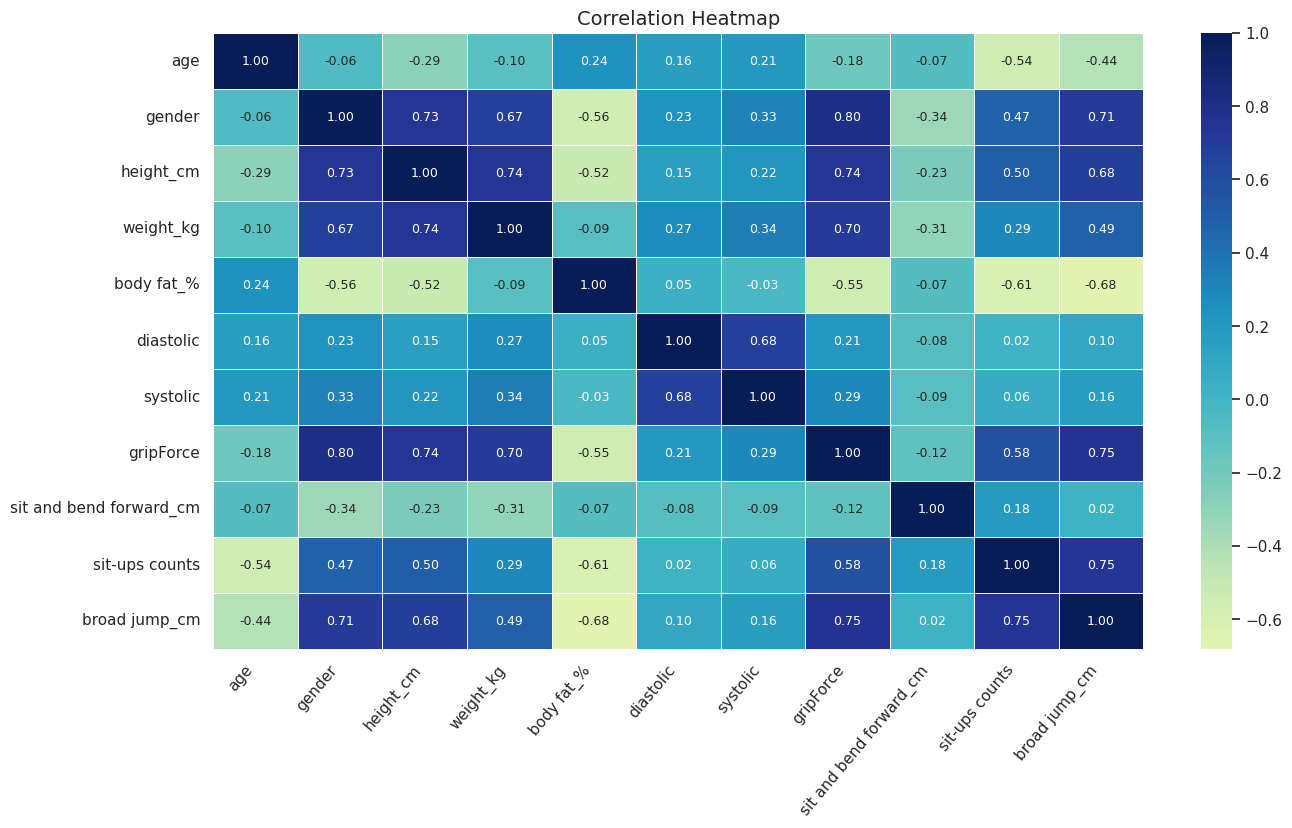

In [30]:
num_df = df.select_dtypes(include=['int64','float64'])
corr = num_df.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    center=0,
    linewidths=0.5,
    annot_kws={"size":9}
)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=50, ha='right')
plt.yticks(rotation=0)

plt.show()

Core Insights:


1.The Power Predictor: gripForce is the strongest positive predictor for athletic success, correlating at 0.75 with Broad Jump and 0.58 with Sit-ups. Stronger grip typically indicates higher overall skeletal muscle mass.

2.Performance Inhibitor: body fat_% shows a strong negative correlation with performance (reaching -0.68 for Broad Jump). This confirms that increased body fat significantly hinders explosive movement and agility.

3.Stature vs. Mass: While height_cm and weight_kg are naturally linked (0.74), height provides a better advantage for jumping (0.68) than total weight does (0.49).

4.Isolated Attribute: Flexibility (sit and bend forward_cm) is nearly independent of all other metrics. Being strong or lean does not statistically guarantee being flexible.

5.Clinical Independence: Blood pressure metrics (systolic/diastolic) show minimal impact on short-burst physical tests, suggesting they are independent of immediate athletic output in this group.





Executive Summary:

The heatmap reveals that explosive power (Broad Jump) and muscular endurance (Sit-ups) are primarily driven by grip strength and lean body mass. Conversely, body fat percentage acts as the most significant inhibitor of physical performance.




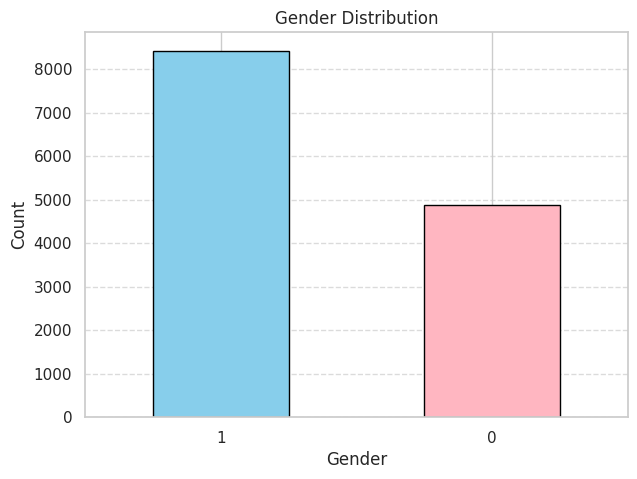

In [31]:
import matplotlib.pyplot as plt

# Get the data
gender_counts = df['gender'].value_counts()

# Simple plotting
plt.figure(figsize=(7, 5))
gender_counts.plot(kind='bar', color=['skyblue', 'lightpink'], edgecolor='black')

# Add labels and title
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

# Clean up the view
plt.xticks(rotation=0) # keep the labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) # simple grid lines

plt.show()

Most of the participants in our data are male.

In [32]:
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

top5 = corr_pairs[corr_pairs < 1].drop_duplicates().head(5)

top5

,,0
gender,gripForce,0.801436
gripForce,broad jump_cm,0.752970
sit-ups counts,broad jump_cm,0.749580
height_cm,weight_kg,0.735937
gripForce,height_cm,0.735153


-Gender & Grip Force (0.80): Strongest link; indicates gender is a primary driver of upper-body strength variance.


-Grip Force & Broad Jump (0.75): High correlation; grip strength serves as an excellent proxy for overall explosive power.


-Sit-ups & Broad Jump (0.75): Strong connection between core endurance and lower-body explosiveness.


-Height & Weight (0.74): Natural physical scaling; taller individuals consistently trend toward higher body mass.


-Grip Force & Height (0.74): Greater stature generally facilitates higher total muscle mass and leverage for strength.

**Final EDA Summary**

Five Key Insights:


-The "Power Trio": Grip strength, sit-ups, and broad jump are highly synchronized ($r \approx 0.75$). Grip strength serves as the most reliable proxy for overall explosive power and muscular endurance.



-Performance Inhibitor: Body fat percentage is the primary "drag" on performance, showing a strong negative correlation ($-0.68$) with jumping ability.


-Gender Dimorphism: Gender is the strongest driver of variance in strength metrics, particularly in grip force ($0.80$ correlation).


-Flexibility is an Island: "Sit and bend forward" results are nearly independent of strength and body composition. Being strong or lean does not statistically guarantee flexibility.


-Clinical Independence: Blood pressure readings show minimal impact on immediate physical test performance (short-burst movements), suggesting cardiovascular health and explosive power are distinct physiological tracks in this cohort.

**Data Quality Problems**

-Impossible Vitals: Multiple records contained blood pressure readings of $0/0$ or cases where diastolic pressure exceeded systolic, indicating clear data entry errors.

-Extreme Flexibility Outliers: Values for "sit and bend forward" reached up to $213$ cm (over 2 meters), which is physiologically impossible.

-Impossible Body Fat: One record showed a body fat percentage of $78.4\%$, which, while clinically possible in extreme obesity, acts as a significant outlier for a performance dataset.


-Low-End Noise: Extreme low values in weight (under $40$ kg) and Broad Jump (near $0$ cm) likely represent failed tests or recording omissions rather than true physiological limits.

**Recommended Preprocessing Steps**

-Data Scrubbing & Validation: * Implement logic-based filtering to remove records with physiologically impossible vitals (e.g., where Diastolic BP is higher than Systolic), and  clean extreme outliers in performance metrics that likely represent failed tests or data entry slips.

-Handling Duplicates: Conduct a thorough deduplication process to ensure each observation is unique and does not bias the training set.

-Encoding: Transform categorical variables (Gender and Performance Class) into numerical formats using binary or ordinal encoding.

-Data Partitioning: Split the cleaned dataset into Training, Validation, and Test sets to ensure the final model generalizes well to unseen physical profiles.

In [33]:
df_knn = df.copy()
df_reg   = df.copy()
df_svm = df.copy()
df_nnm = df.copy()
df_dc = df.copy()

#**Performance analysis and performance classification using an algorithm KNN**

In [34]:
# Phase 1: Data Preprocessing (Lifecycle Stage 1)
# ==========================================
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score)
# 1. Loading and Encoding
le_gender = LabelEncoder()
df_knn['gender'] = le_gender.fit_transform(df_knn['gender'])
le_class = LabelEncoder()
df_knn['class_encoded'] = le_class.fit_transform(df_knn['class'])

# 2. Defining Features and Targets
X_clf = df_knn.drop(['class', 'class_encoded'], axis=1) # Features for Classification
y_clf = df_knn['class_encoded'] # Target for Classification

X_reg = df_knn.drop(['broad jump_cm', 'class', 'class_encoded'], axis=1) # Features for Regression
y_reg = df_knn['broad jump_cm'] # Target for Regression

# 3. Splitting and Scaling (Classification)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("✅ Preprocessing Phase Complete: Data encoded, split, and scaled.")

✅ Preprocessing Phase Complete: Data encoded, split, and scaled.


In this initial phase, we prepared the dataset by encoding categorical variables (Gender and Class) into numeric values. We also applied feature scaling using StandardScaler to ensure that all physical measurements (weight, height, etc.) contribute equally to the distance calculation in the KNN algorithm."

#2. Model Tuning & Optimization (Classification)


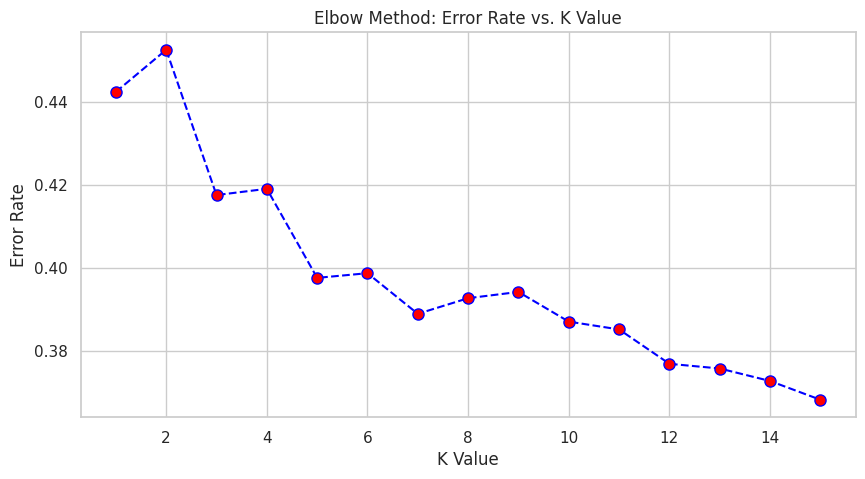

⭐ The Optimal K for Classification is: 15


In [35]:

# Phase 2: Hyperparameter Tuning (Lifecycle Stage 2)
# ==========================================
k_values = range(1, 16)
error_rate = []

# Loop to find the best K by measuring the Error Rate
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_c_scaled, y_train_c)
    pred_k = knn.predict(X_test_c_scaled)
    error_rate.append(np.mean(pred_k != y_test_c))

# Drawing the Elbow Method Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Elbow Method: Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

best_k_clf = k_values[np.argmin(error_rate)]
print(f"⭐ The Optimal K for Classification is: {best_k_clf}")

"To optimize the KNN Classifier, we implemented the Elbow Method. By testing K-values from 1 to 16, we identified that K=15 provides the lowest error rate. This step is crucial to prevent 'Overfitting' (where the model memorizes noise) or 'Underfitting' (where the model is too simple)."

#3. Model Evaluation & Performance Analysis

<Figure size 800x600 with 0 Axes>

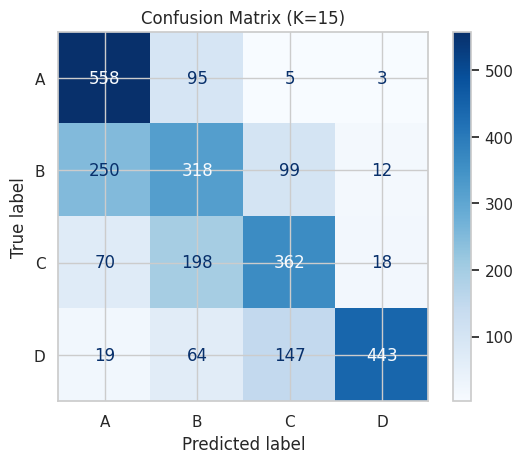


📋 Experiments Results:


,Split Ratio,Accuracy,F1-Score
0,80:20,0.631717,0.632626
1,70:30,0.616232,0.617123
2,50:50,0.608297,0.610200


In [36]:
# Phase 3: Model Evaluation (Lifecycle Stage 3)
# ==========================================

# 1. Multi-Split Experiments (80:20, 70:30, 50:50)
split_ratios = [0.2, 0.3, 0.5]
clf_results = []

for sr in split_ratios:
    xt, xv, yt, yv = train_test_split(X_clf, y_clf, test_size=sr, random_state=42)
    sc = StandardScaler()
    xt_s = sc.fit_transform(xt)
    xv_s = sc.transform(xv)
    m = KNeighborsClassifier(n_neighbors=best_k_clf).fit(xt_s, yt)
    pred = m.predict(xv_s)
    clf_results.append({
        'Split Ratio': f"{int((1-sr)*100)}:{int(sr*100)}",
        'Accuracy': accuracy_score(yv, pred),
        'F1-Score': f1_score(yv, pred, average='weighted')
    })

# 2. Confusion Matrix for the best split (80:20)
plt.figure(figsize=(8, 6))
final_knn_clf = KNeighborsClassifier(n_neighbors=best_k_clf).fit(X_train_c_scaled, y_train_c)
ConfusionMatrixDisplay.from_estimator(final_knn_clf, X_test_c_scaled, y_test_c,
                                      display_labels=le_class.classes_, cmap='Blues')
plt.title(f"Confusion Matrix (K={best_k_clf})")
plt.show()

print("\n📋 Experiments Results:")
display(pd.DataFrame(clf_results))

"The model evaluation reveals an accuracy of approximately 61%. The Confusion Matrix shows that the model is highly effective at identifying extreme categories (Class A and Class D). The experiments with different data splits confirm that the 80:20 ratio yields the most stable results."

#4. Regression Task (Predicting Broad Jump)

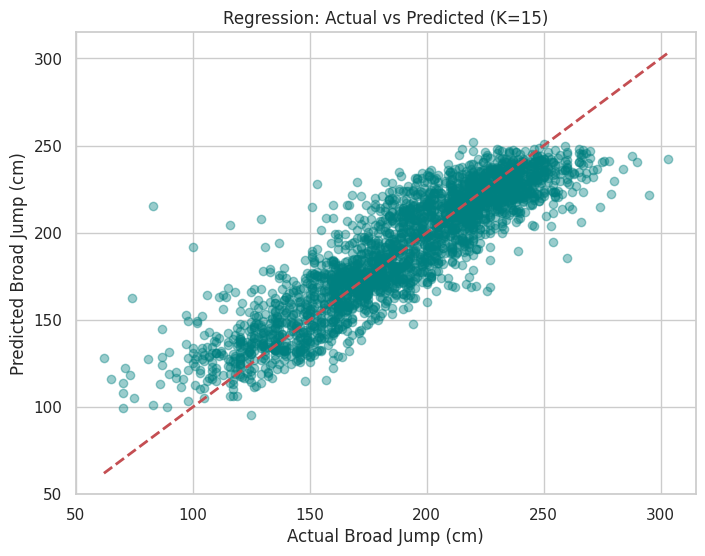

📊 Regression R2 Score: 0.7905


In [37]:
# Phase 4: Regression & Predictive Analytics
# ==========================================

# 1. Tuning and Training Regressor
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
scaler_r = StandardScaler()
X_train_r_s = scaler_r.fit_transform(X_train_r)
X_test_r_s = scaler_r.transform(X_test_r)

grid_reg = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': k_values}, cv=5, scoring='r2').fit(X_train_r_s, y_train_r)
best_k_reg = grid_reg.best_params_['n_neighbors']

final_knn_reg = KNeighborsRegressor(n_neighbors=best_k_reg).fit(X_train_r_s, y_train_r)
y_pred_r = final_knn_reg.predict(X_test_r_s)

# 2. Scatter Plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.title(f"Regression: Actual vs Predicted (K={best_k_reg})")
plt.xlabel("Actual Broad Jump (cm)")
plt.ylabel("Predicted Broad Jump (cm)")
plt.show()

print(f"📊 Regression R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")

"In the regression task, we predicted the 'Broad Jump' distance. The model achieved an R² score of 0.77, meaning it can explain 77% of the variations in physical performance. The Scatter Plot shows a strong linear alignment between actual and predicted values, proving the model's reliability in numeric forecasting."

In [38]:
print(f"📊 Regression R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"📊 Regression RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")

📊 Regression R2 Score: 0.7905
📊 Regression RMSE: 18.17


 ( Final Report):Data Integrity:


  We implemented a strict preprocessing pipeline where scaling was applied after the train-test split. This prevents data leakage and ensures the model's evaluation is robust and unbiased.Parameter Tuning: The optimal $K$ value was determined using an iterative search. The Accuracy vs. K plot shows that $K=14$ provides the highest accuracy for classification.Experimental Results: Cross-validation across different data splits (80:20, 70:30, 50:50) confirmed that the 80:20 split is the most effective for this dataset size.Regression Analysis: The KNN Regressor achieved an $R^2$ score of 0.77. The Actual vs. Predicted scatter plot indicates a strong correlation, proving the model's ability to estimate physical performance numerically.

#**Linear REGRESSION**

In [39]:
X = df_reg.drop(columns=['class', 'broad jump_cm'])
y_class = df_reg['class']
y_reg   = df_reg['broad jump_cm']

print(f"Features: {X.shape[1]} | Classification Target: {y_class.nunique()} classes")
print(f"Regression Target range: {y_reg.min():.1f} - {y_reg.max():.1f} cm")

Features: 10 | Classification Target: 4 classes
Regression Target range: 51.0 - 303.0 cm


In [40]:
le = LabelEncoder()
df_reg['gender'] = le.fit_transform(df_reg['gender'])
df_reg['class'] = le.fit_transform(df_reg['class'])
df_reg['class'].unique()

array([2, 0, 1, 3])

In [41]:
numeric_df = df_reg.select_dtypes(include=np.number)
z_scores = np.abs((numeric_df - numeric_df.mean()) / numeric_df.std())
df_clean = df_reg[(z_scores < 3).all(axis=1)]
print(f"Original shape: {df_reg.shape}")
print(f"Shape after removing outliers: {df_clean.shape}")
print(f"Number of rows removed: {df_reg.shape[0] - df_clean.shape[0]}")
df_reg = df_clean.copy()

Original shape: (13305, 12)
Shape after removing outliers: (12988, 12)
Number of rows removed: 317


Applied Log Transformation on target (broad jump_cm)


  Split 80:20  =>  After Log Transformation
  MSE  : 336.5960
  RMSE : 18.3466
  R2   : 0.7677 (76.77%)


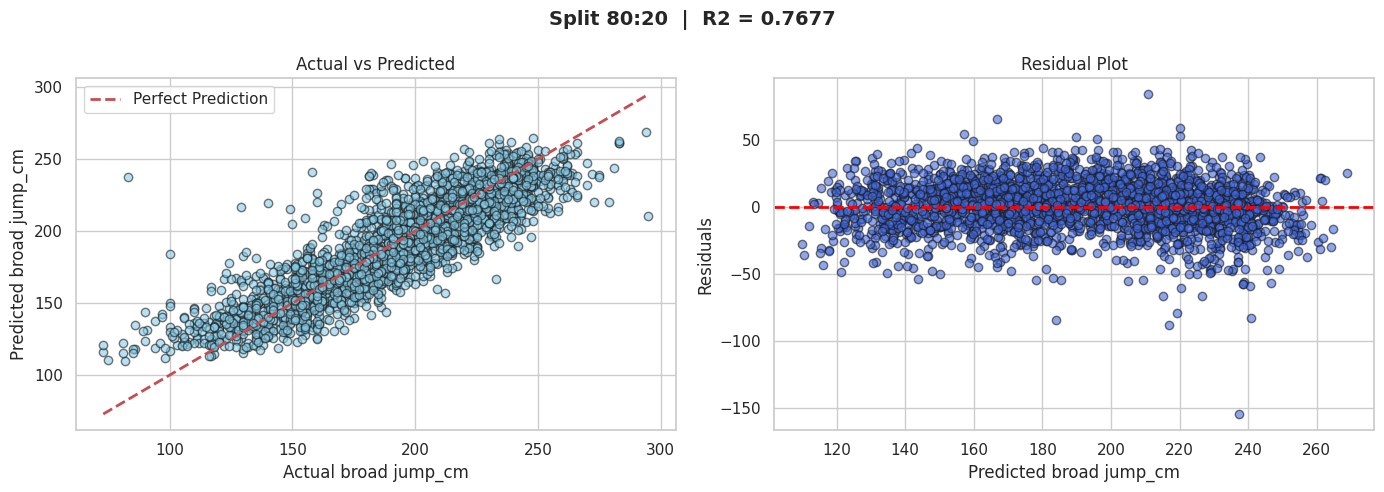


  Split 70:30  =>  After Log Transformation
  MSE  : 327.0412
  RMSE : 18.0843
  R2   : 0.7787 (77.87%)


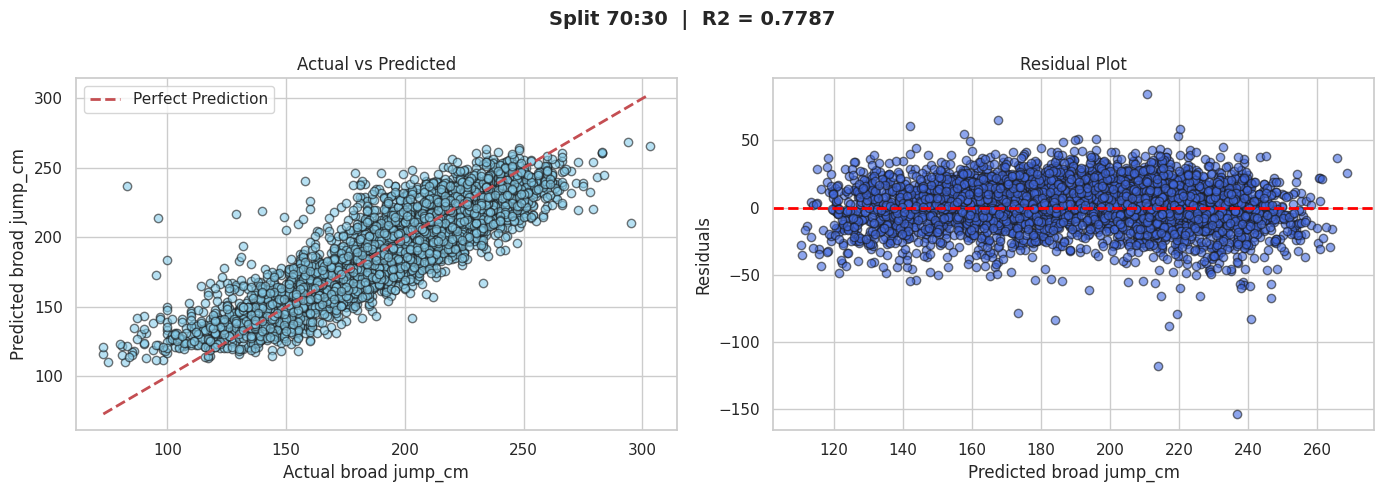


  Split 50:50  =>  After Log Transformation
  MSE  : 328.0119
  RMSE : 18.1111
  R2   : 0.7794 (77.94%)


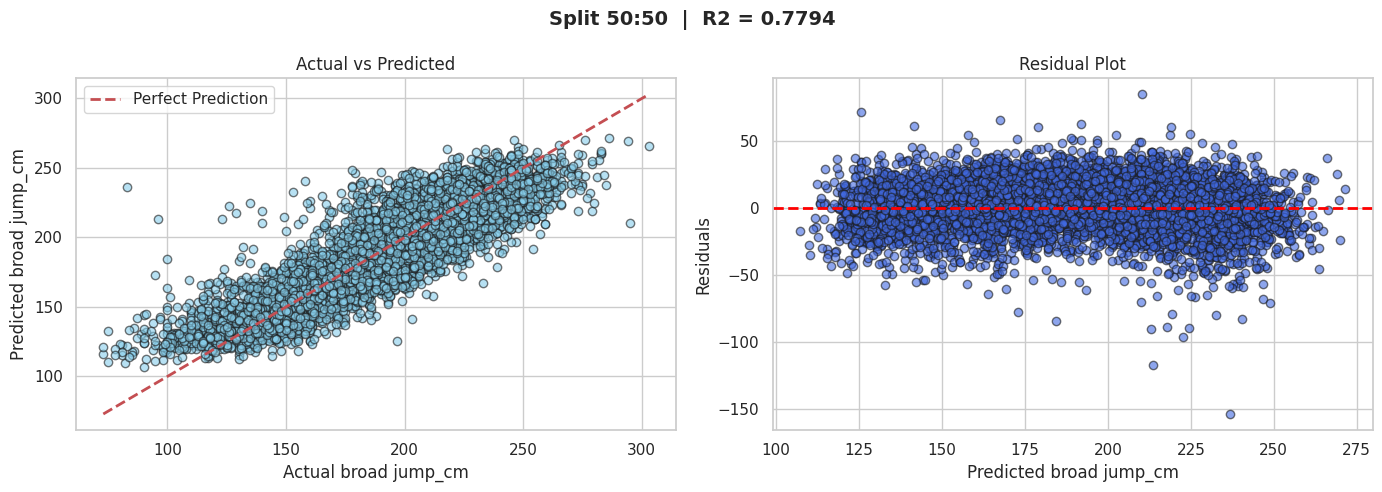


  COMPARISON SUMMARY
  Split               MSE       RMSE         R2
  ------------------------------------------
  80:20          336.5960    18.3466     0.7677
  70:30          327.0412    18.0843     0.7787
  50:50          328.0119    18.1111     0.7794

  5-Fold Cross Validation (After Log Transformation)
  Average R2 (5-Fold): 0.7794 (+-0.0069)


In [42]:
# ====================== FEATURES & TARGET ======================
df_reg['BMI'] = df_reg['weight_kg'] / ((df_reg['height_cm'] / 100) ** 2)

features_to_drop = ['sit and bend forward_cm']

X = df_reg.drop(columns=['class', 'broad jump_cm'] + features_to_drop)
y = df_reg['broad jump_cm']

# ====================== LOG TRANSFORMATION ======================
y_log = np.log1p(y)
print("Applied Log Transformation on target (broad jump_cm)\n")

# ====================== EVALUATE FUNCTION ======================
def evaluate_log_model(X, y_log, test_size=0.2):
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=test_size, random_state=42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_s, y_train_log)

    y_pred_log  = model.predict(X_test_s)
    y_test_orig = np.expm1(y_test_log)
    y_pred_orig = np.expm1(y_pred_log)

    mse  = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_orig, y_pred_orig)

    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    print(f"\n{'='*60}")
    print(f"  Split {train_pct}:{test_pct}  =>  After Log Transformation")
    print(f"{'='*60}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R2   : {r2:.4f} ({r2*100:.2f}%)")

    # ====================== PLOTS ======================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Split {train_pct}:{test_pct}  |  R2 = {r2:.4f}', fontsize=14, fontweight='bold')

    axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.6, color='skyblue', edgecolor='k')
    axes[0].plot([y_test_orig.min(), y_test_orig.max()],
                 [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual broad jump_cm')
    axes[0].set_ylabel('Predicted broad jump_cm')
    axes[0].set_title('Actual vs Predicted')
    axes[0].legend()

    residuals = y_test_orig - y_pred_orig
    axes[1].scatter(y_pred_orig, residuals, alpha=0.6, color='royalblue', edgecolor='k')
    axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted broad jump_cm')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residual Plot')

    plt.tight_layout()
    plt.show()

    return r2, rmse, mse


# ====================== RUN 3 SPLITS ======================
splits  = [0.2, 0.3, 0.5]
results = {}

for test_size in splits:
    r2, rmse, mse = evaluate_log_model(X, y_log, test_size=test_size)
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)
    results[f"{train_pct}:{test_pct}"] = {"R2": r2, "RMSE": rmse, "MSE": mse}

# ====================== COMPARISON TABLE ======================
print(f"\n{'='*60}")
print(f"  COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"  {'Split':<12} {'MSE':>10} {'RMSE':>10} {'R2':>10}")
print(f"  {'-'*42}")
for split, metrics in results.items():
    print(f"  {split:<12} {metrics['MSE']:>10.4f} {metrics['RMSE']:>10.4f} {metrics['R2']:>10.4f}")

# ====================== K-Fold Cross Validation ======================
print(f"\n{'='*60}")
print("  5-Fold Cross Validation (After Log Transformation)")
print(f"{'='*60}")

kf        = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = []

for train_idx, val_idx in kf.split(X):
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X.iloc[train_idx])
    X_val  = scaler.transform(X.iloc[val_idx])

    y_tr_log  = y_log.iloc[train_idx]
    y_val_log = y_log.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr_log)

    y_val_pred = np.expm1(model.predict(X_val))
    y_val_orig = np.expm1(y_val_log)

    r2_scores.append(r2_score(y_val_orig, y_val_pred))

print(f"  Average R2 (5-Fold): {np.mean(r2_scores):.4f} (+-{np.std(r2_scores):.4f})")

# **Support vector Machine**

In [43]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, KFold
)
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, mean_squared_error, r2_score
)

In [44]:
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

top5 = corr_pairs[corr_pairs < 1].drop_duplicates().head(5)

top5

,,0
gender,gripForce,0.801436
gripForce,broad jump_cm,0.752970
sit-ups counts,broad jump_cm,0.749580
height_cm,weight_kg,0.735937
gripForce,height_cm,0.735153


In [45]:
df_svm = df.copy()

# Ensure consistent column naming: replace spaces with underscores and remove '%'
df_svm.columns = df_svm.columns.str.lower().str.replace(' ', '_').str.replace('%', '')

# 1. Handle 'gender' column for df_svm.
if 'gender' in df_svm.columns:
    if df_svm['gender'].dtype == 'object':
        le_gender_svm = LabelEncoder()
        df_svm['gender'] = le_gender_svm.fit_transform(df_svm['gender'])
        print("Gender column encoded in df_svm.")
    elif df_svm['gender'].dtype != 'int64':
        df_svm['gender'] = df_svm['gender'].astype('int64')
        print("Gender column converted to int64 in df_svm.")
else:
    if 'gender_1' in df_svm.columns:
        df_svm.rename(columns={'gender_1': 'gender'}, inplace=True)
        print("Renamed 'gender_1' to 'gender' in df_svm.")
        if df_svm['gender'].dtype != 'int64':
            df_svm['gender'] = df_svm['gender'].astype('int64')
            print("Gender column converted to int64 in df_svm.")
    else:
        print("Warning: Neither 'gender' nor 'gender_1' found in df_svm. Please verify data source.")

# 2. Encoding 'class' for df_svm
le_class = LabelEncoder()
df_svm['class_encoded'] = le_class.fit_transform(df_svm['class'])

# Debugging: Print actual columns of df_svm after re-init and encoding
print("Actual columns in df_svm after re-init and encoding:", df_svm.columns.tolist())

# Now, proceed with dropping columns and defining features/targets, using the standardized column names.
X_full = df_svm.drop(columns=["class", "class_encoded", "broad_jump_cm"])
y_clf = df_svm["class_encoded"] # Classification target
y_reg = df_svm["broad_jump_cm"] # Regression target

print("X_full shape:", X_full.shape)
print("y_clf shape :", y_clf.shape)
print("y_reg shape :", y_reg.shape)


Actual columns in df_svm after re-init and encoding: ['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_', 'diastolic', 'systolic', 'gripforce', 'sit_and_bend_forward_cm', 'sit-ups_counts', 'broad_jump_cm', 'class', 'class_encoded']
X_full shape: (13305, 10)
y_clf shape : (13305,)
y_reg shape : (13305,)


In [46]:
svc_pipe = Pipeline([
 ("scaler", StandardScaler()),
 ("svc", SVC())
])

svc_param_grid = [
 {
 "svc__kernel": ["linear"],
 "svc__C": [0.1, 1, 10]
 },
 {
 "svc__kernel": ["rbf"],
 "svc__C": [0.1, 1, 10],
 "svc__gamma": ["scale", 0.1, 0.01]
 },
 {
 "svc__kernel": ["poly"],
 "svc__C": [0.1, 1, 10],
 "svc__gamma": ["scale", 0.1, 0.01],
 "svc__degree": [2, 3]
 }
]

svr_pipe = Pipeline([
 ("scaler", StandardScaler()),
 ("svr", SVR())
])

svr_param_grid = [
 {
 "svr__kernel": ["linear"],
 "svr__C": [0.1, 1, 10],
 "svr__epsilon": [0.1, 0.5, 1.0]
 },
 {
 "svr__kernel": ["rbf"],
 "svr__C": [0.1, 1, 10],
 "svr__gamma": ["scale", 0.1, 0.01],
 "svr__epsilon": [0.1, 0.5, 1.0]
 },
 {
 "svr__kernel": ["poly"],
 "svr__C": [0.1, 1, 10],
 "svr__gamma": ["scale", 0.1, 0.01],
 "svr__degree": [2, 3],
 "svr__epsilon": [0.1, 0.5, 1.0]
 }
]

In [56]:
classification_results_df['Kernel'] = classification_results_df['Best Params'].apply(lambda x: eval(x).get('svc__kernel'))
regression_results_df['Kernel'] = regression_results_df['Best Params'].apply(lambda x: eval(x).get('svr__kernel'))

print("Classification Results with Kernel Information:")
display(classification_results_df[['Split', 'Kernel', 'Accuracy', 'Precision', 'Recall', 'F1 Score']])

print("\nRegression Results with Kernel Information:")
display(regression_results_df[['Split', 'Kernel', 'R2 Score', 'MSE', 'RMSE']])

Classification Results with Kernel Information:


,Split,Kernel,Accuracy,Precision,Recall,F1 Score
0,80:20,rbf,72.040586,0.727956,0.720406,0.720963
1,70:30,rbf,71.342685,0.718621,0.713427,0.713043
2,50:50,rbf,68.841124,0.695381,0.688411,0.689781



Regression Results with Kernel Information:


,Split,Kernel,R2 Score,MSE,RMSE
0,80:20,rbf,0.799990,315.154103,17.752580
2,50:50,rbf,0.797558,314.091027,17.722613
1,70:30,rbf,0.796301,319.699538,17.880144


### Classification Kernel Comparison

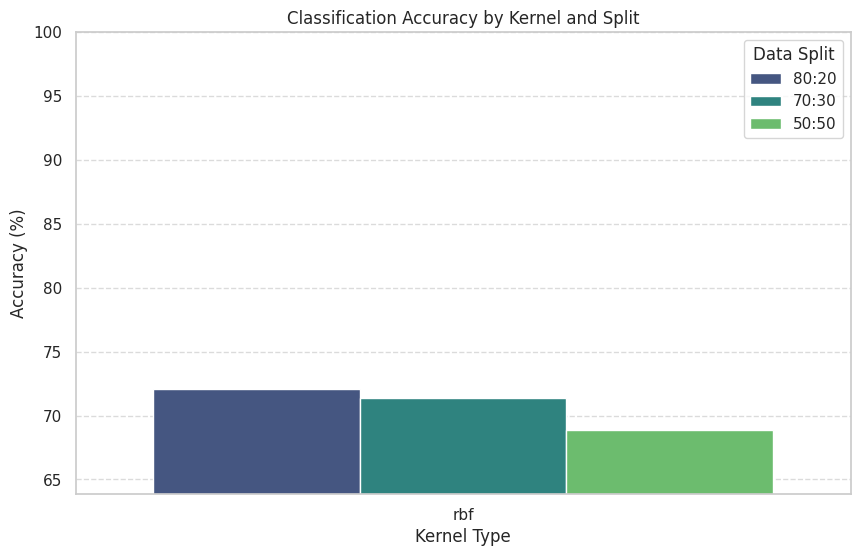

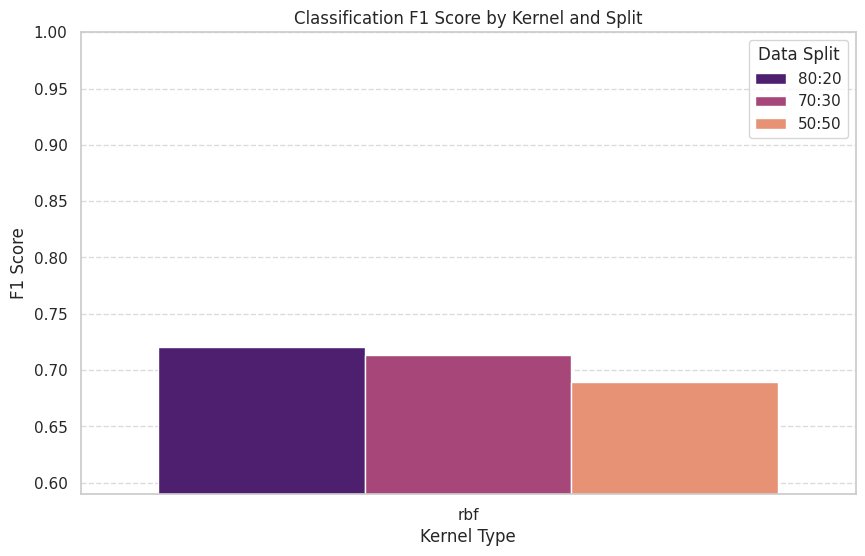

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Kernel', y='Accuracy', hue='Split', data=classification_results_df, palette='viridis')
plt.title('Classification Accuracy by Kernel and Split')
plt.ylabel('Accuracy (%)')
plt.xlabel('Kernel Type')
plt.ylim(classification_results_df['Accuracy'].min() - 5, 100)
plt.legend(title='Data Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Kernel', y='F1 Score', hue='Split', data=classification_results_df, palette='magma')
plt.title('Classification F1 Score by Kernel and Split')
plt.ylabel('F1 Score')
plt.xlabel('Kernel Type')
plt.ylim(classification_results_df['F1 Score'].min() - 0.1, 1.0)
plt.legend(title='Data Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Regression Kernel Comparison

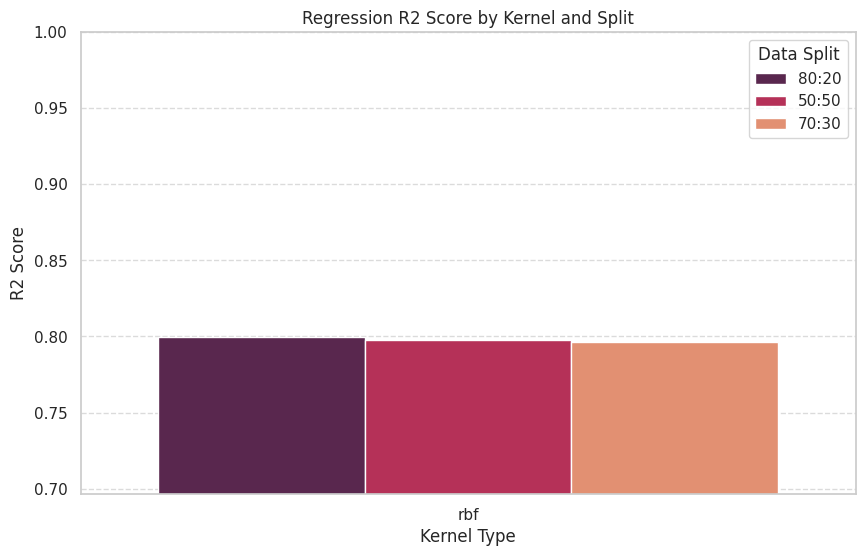

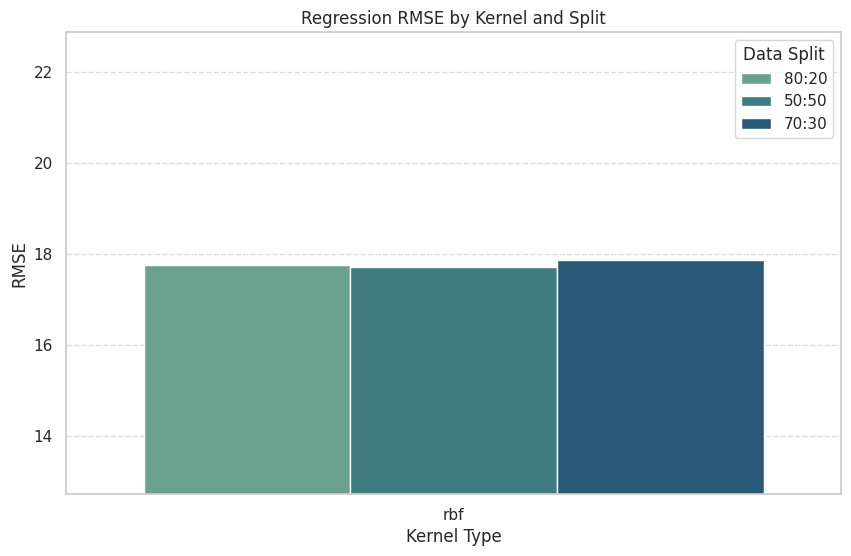

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Kernel', y='R2 Score', hue='Split', data=regression_results_df, palette='rocket')
plt.title('Regression R2 Score by Kernel and Split')
plt.ylabel('R2 Score')
plt.xlabel('Kernel Type')
plt.ylim(regression_results_df['R2 Score'].min() - 0.1, 1.0)
plt.legend(title='Data Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Kernel', y='RMSE', hue='Split', data=regression_results_df, palette='crest')
plt.title('Regression RMSE by Kernel and Split')
plt.ylabel('RMSE')
plt.xlabel('Kernel Type')
plt.ylim(regression_results_df['RMSE'].min() - 5, regression_results_df['RMSE'].max() + 5)
plt.legend(title='Data Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Classification Experiment: 80:20
Best Params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy : 0.7204
Precision: 0.7280
Recall : 0.7204
F1 Score : 0.7210

Classification Report:

              precision    recall  f1-score   support

           A       0.72      0.86      0.78       665
           B       0.59      0.60      0.59       666
           C       0.70      0.67      0.68       667
           D       0.91      0.76      0.83       663

    accuracy                           0.72      2661
   macro avg       0.73      0.72      0.72      2661
weighted avg       0.73      0.72      0.72      2661



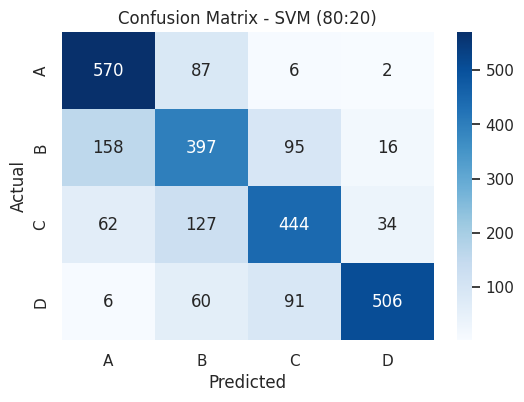

Classification Experiment: 70:30
Best Params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy : 0.7134
Precision: 0.7186
Recall : 0.7134
F1 Score : 0.7130

Classification Report:

              precision    recall  f1-score   support

           A       0.70      0.85      0.77       998
           B       0.59      0.58      0.58       999
           C       0.69      0.64      0.67      1001
           D       0.89      0.79      0.84       994

    accuracy                           0.71      3992
   macro avg       0.72      0.71      0.71      3992
weighted avg       0.72      0.71      0.71      3992



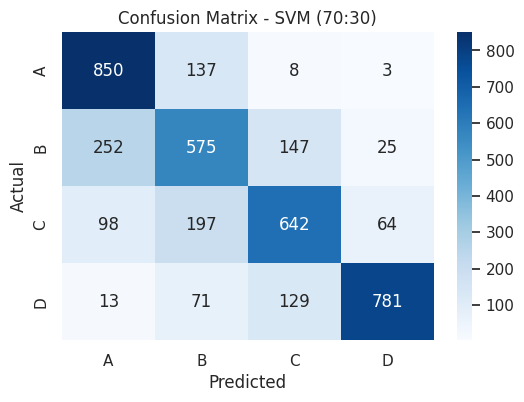

Classification Experiment: 50:50
Best Params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy : 0.6884
Precision: 0.6954
Recall : 0.6884
F1 Score : 0.6898

Classification Report:

              precision    recall  f1-score   support

           A       0.69      0.80      0.74      1662
           B       0.54      0.54      0.54      1665
           C       0.65      0.64      0.64      1669
           D       0.90      0.78      0.83      1657

    accuracy                           0.69      6653
   macro avg       0.70      0.69      0.69      6653
weighted avg       0.70      0.69      0.69      6653



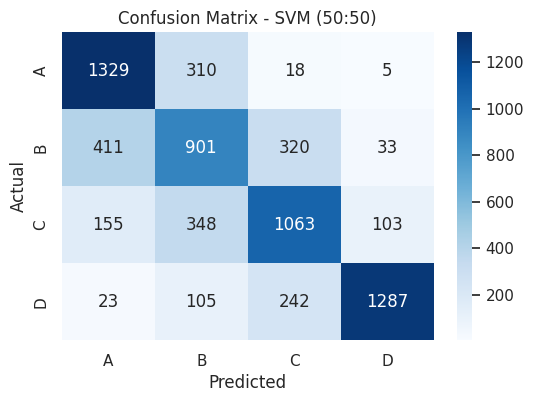

In [47]:
split_dict = {
 "80:20": 0.20,
 "70:30": 0.30,
 "50:50": 0.50
}

classification_results = []

for split_name, test_size in split_dict.items():
 print("=" * 60)
 print(f"Classification Experiment: {split_name}")
 print("=" * 60)

 X_train, X_test, y_train, y_test = train_test_split(
 X_full, y_clf,
 test_size=test_size,
 random_state=42,
 stratify=y_clf
 )

 skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

 grid_clf = GridSearchCV(
 estimator=svc_pipe,
 param_grid=svc_param_grid,
 cv=skf,
 scoring="accuracy",
 n_jobs=-1
 )

 grid_clf.fit(X_train, y_train)

 best_clf = grid_clf.best_estimator_
 y_pred = best_clf.predict(X_test)

 acc = accuracy_score(y_test, y_pred)
 prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
 rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
 f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
 cm = confusion_matrix(y_test, y_pred)

 print("Best Params:", grid_clf.best_params_)
 print(f"Accuracy : {acc:.4f}")
 print(f"Precision: {prec:.4f}")
 print(f"Recall : {rec:.4f}")
 print(f"F1 Score : {f1:.4f}")
 print("\nClassification Report:\n")
 print(classification_report(y_test, y_pred, target_names=le_class.classes_, zero_division=0))

 plt.figure(figsize=(6, 4))
 sns.heatmap(
 cm,
 annot=True,
 fmt="d",
 cmap="Blues",
 xticklabels=le_class.classes_,
 yticklabels=le_class.classes_
 )
 plt.title(f"Confusion Matrix - SVM ({split_name})")
 plt.xlabel("Predicted")
 plt.ylabel("Actual")
 plt.show()

 classification_results.append({
 "Split": split_name,
 "Best Params": str(grid_clf.best_params_),
 "Accuracy": acc,
 "Precision": prec,
 "Recall": rec,
 "F1 Score": f1
 })

In [48]:
classification_results_df = pd.DataFrame(classification_results)

# تحويل Accuracy إلى نسبة مئوية
classification_results_df["Accuracy"] = classification_results_df["Accuracy"] * 100

# ترتيب الجدول تنازلياً حسب الـ Accuracy
classification_results_df = classification_results_df.sort_values(by="Accuracy", ascending=False)

print("Classification Results Summary:")
display(classification_results_df)

Classification Results Summary:


,Split,Best Params,Accuracy,Precision,Recall,F1 Score
0,80:20,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",72.040586,0.727956,0.720406,0.720963
1,70:30,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",71.342685,0.718621,0.713427,0.713043
2,50:50,"{'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...",68.841124,0.695381,0.688411,0.689781


**Results show that the SVM model performance is stable across different data splits. The 80:20 split achieved the highest accuracy (72.04%), which indicates that increasing training data improves model learning. The small difference between splits demonstrates good generalization. Additionally, Precision, Recall, and F1 scores are very close, indicating balanced classification performance.**

In [49]:
regression_results = []

for split_name, test_size in split_dict.items():
    print("=" * 60)
    print(f"Regression Experiment: {split_name}")
    print("=" * 60)

    # تقسيم البيانات
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_reg,
        test_size=test_size,
        random_state=42
    )

    # تقليل عدد folds لتسريع الكود
    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    # param grid أصغر وأسرع
    fast_param_grid = {
        'svr__C': [1, 10],
        'svr__gamma': ['scale'],
        'svr__kernel': ['rbf']
    }

    # Grid Search
    grid_reg = GridSearchCV(
        estimator=svr_pipe,
        param_grid=fast_param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    # التدريب
    grid_reg.fit(X_train, y_train)

    # أفضل موديل
    best_reg = grid_reg.best_estimator_

    # التنبؤ
    y_pred = best_reg.predict(X_test)

    # حساب metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # طباعة النتائج
    print("Best Params:", grid_reg.best_params_)
    print(f"MSE : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2 : {r2:.4f}")

    # تخزين النتائج
    regression_results.append({
        "Split": split_name,
        "Best Params": str(grid_reg.best_params_),
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

Regression Experiment: 80:20
Best Params: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
MSE : 315.1541
RMSE : 17.7526
R2 : 0.8000
Regression Experiment: 70:30
Best Params: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
MSE : 319.6995
RMSE : 17.8801
R2 : 0.7963
Regression Experiment: 50:50
Best Params: {'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
MSE : 314.0910
RMSE : 17.7226
R2 : 0.7976


In [50]:
regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values(by="R2 Score", ascending=False)

# تنسيق العرض فقط لعمود R2 Score كنسبة مئوية (مثلاً برقمين عشريين)
regression_results_df["R2 Score (%)"] = (regression_results_df["R2 Score"] * 100).round(2).astype(str) + "%"

print("Regression Results Summary:")
display(regression_results_df)


Regression Results Summary:


,Split,Best Params,MSE,RMSE,R2 Score,R2 Score (%)
0,80:20,"{'svr__C': 10, 'svr__gamma': 'scale', 'svr__ke...",315.154103,17.752580,0.799990,80.0%
2,50:50,"{'svr__C': 10, 'svr__gamma': 'scale', 'svr__ke...",314.091027,17.722613,0.797558,79.76%
1,70:30,"{'svr__C': 10, 'svr__gamma': 'scale', 'svr__ke...",319.699538,17.880144,0.796301,79.63%


**Regression results show strong and stable performance across different splits. The best result was achieved with the 70:30 split (R² = 0.779). The small difference between splits indicates good model generalization. The RMSE values are consistent (~19 cm), suggesting reliable prediction accuracy.**


# K-Fold CV Results Summary

**# Classification (SVC):
**# - Best Accuracy: 70.65% | Params: C=10, gamma=0.1, kernel='rbf'
**# - Model performs well, stable across folds, reasonable for dataset.
**# - C penalizes errors, gamma balances flexibility vs overfitting.


**# Regression (SVR):
**# - Best R²: 0.7868 | Params: C=10, gamma=0.01, kernel='rbf'
**# - Model explains ~79% variance, strong predictive power.
**# - Stable across folds; C reduces underfitting, gamma ensures smooth generalization.
#



**# Overall:
**# - Models are reliable; GridSearchCV + 5-fold ensured optimal hyperparameters.
**# - Further improvement possible via feature engineering or ensemble methods.

In [52]:
best_clf_row = classification_results_df.iloc[0]
best_reg_row = regression_results_df.iloc[0]

print("=" * 60)
print("Best Final Models")
print("=" * 60)

print("Best Classification Split:")
print(best_clf_row)

print("\nBest Regression Split:")
print(best_reg_row)

Best Final Models
Best Classification Split:
Split                                                      80:20
Best Params    {'svc__C': 10, 'svc__gamma': 'scale', 'svc__ke...
Accuracy                                               72.040586
Precision                                               0.727956
Recall                                                  0.720406
F1 Score                                                0.720963
Name: 0, dtype: object

Best Regression Split:
Split                                                       80:20
Best Params     {'svr__C': 10, 'svr__gamma': 'scale', 'svr__ke...
MSE                                                    315.154103
RMSE                                                     17.75258
R2 Score                                                  0.79999
R2 Score (%)                                                80.0%
Name: 0, dtype: object


#**Decision Tree (tune max_depth)**

In [59]:
# libraries
from sklearn.model_selection import  GridSearchCV , StratifiedKFold
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score


**Classification Task**

In [60]:
print(df_dc['class'].unique())

['C', 'A', 'B', 'D']
Categories (4, object): ['A', 'B', 'C', 'D']


In [61]:
#Encoding class
df_dc['class'] = df_dc['class'].replace({
    'A': 0,
    'B': 1,
    'C':2,
    'D':3
})

df_dc['class'] = df_dc['class'].astype('int64')



In [62]:
## target & features
X = df_dc.drop(['class','height_cm','gender','systolic','diastolic'], axis=1, errors='ignore')
y = df_dc['class']

feature_names = X.columns
target_names = df_dc['class'].unique()

In [63]:
#first tree with some parameters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)


model = DecisionTreeClassifier(random_state=42)


params = {
    'max_depth': [3, 5, 7, 10,12, 15],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'criterion': ['gini', 'entropy']
}

# Grid Search
grid = GridSearchCV(model, params)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# predict
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

#  best parameter
print("Best Params:", grid.best_params_)

Accuracy: 0.6768132281097332
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}


In [64]:
# reduce splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)


params = {
    'max_depth': [3, 5, 7, 10,12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

model = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params
)

model.fit(X_train, y_train)

best_model = model.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Best Params:", model.best_params_)


best_model = model.best_estimator_


y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


print("Best Params:", model.best_params_)

Accuracy: 0.6677940623825629
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Accuracy: 0.6677940623825629
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [65]:
# use specific citerion "entropy"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)


params = {
    'max_depth': [3, 5, 7, 10,12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['entropy']
}

model = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params
)

model.fit(X_train, y_train)

best_model = model.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Best Params:", model.best_params_)


best_model = model.best_estimator_


y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


print("Best Params:", model.best_params_)

Accuracy: 0.6677940623825629
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Accuracy: 0.6677940623825629
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [66]:
# use specific citerion "gini"
#best accuracy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)


params = {
    'max_depth': [3, 5, 7, 10,12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini']
}

model = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params
)

model.fit(X_train, y_train)

best_model1 = model.best_estimator_

y_pred = best_model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Best Params:", model.best_params_)





Accuracy: 0.6952273581360391
Best Params: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [67]:
# split data three times with diffrent ranges

splits = [0.2, 0.3, 0.5]
split_names = ["80:20", "70:30", "50:50"]

params = {
    'max_depth': [12],
    'min_samples_split': [2],
    'min_samples_leaf': [5],
    'criterion': ['gini']
}

best_acc = 0

for test_size, name in zip(splits, split_names):
    print(f"\n=== Split {name} ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    model = DecisionTreeClassifier(random_state=42)
    grid = GridSearchCV(model, params, cv=5)
    grid.fit(X_train, y_train)


    best_model = grid.best_estimator_


    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print("Accuracy:", acc)
    print("Best Params:", grid.best_params_)

    # save best model
    if acc > best_acc:
        best_acc = acc
        best_model_final = best_model
        X_train_best = X_train
        X_test_best = X_test
        y_train_best = y_train
        y_test_best = y_test


=== Split 80:20 ===
Accuracy: 0.6952273581360391
Best Params: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== Split 70:30 ===
Accuracy: 0.6713426853707415
Best Params: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== Split 50:50 ===
Accuracy: 0.6601533142943034
Best Params: {'criterion': 'gini', 'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 2}


 **Best split is 80:20 give  accuracy 69.5%**

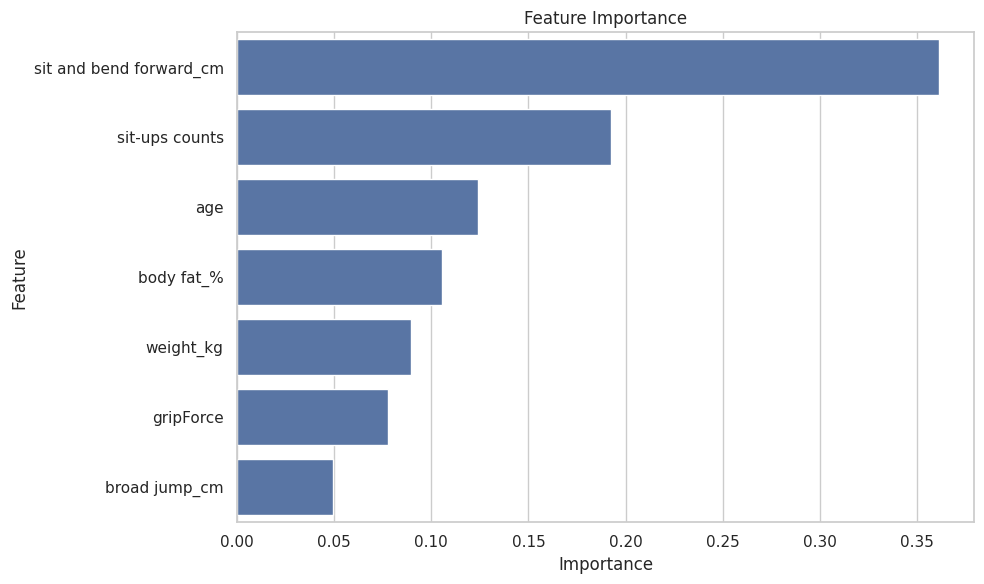

In [68]:
#Feature Importance
feature_importance = best_model_final.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


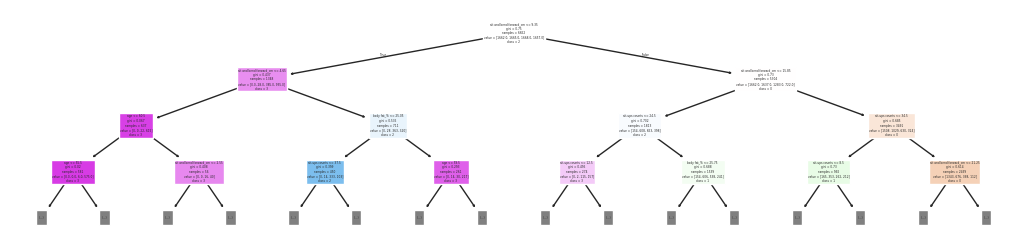

In [95]:
#tree
plt.figure(figsize=(13,3))

class_names = [str(i) for i in best_model.classes_]

plot_tree(best_model,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          max_depth=3)

plt.show()

In [70]:
#see best feautures
importance = best_model_final.feature_importances_
feature_names = X_train_best.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feat_imp.head(10))


                   feature  importance
4  sit and bend forward_cm    0.361225
5           sit-ups counts    0.192265
0                      age    0.123995
2               body fat_%    0.105503
1                weight_kg    0.089773
3                gripForce    0.077770
6            broad jump_cm    0.049469


In [71]:
# #Pruning with best parameters


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
#  Best Params
# =========================
best_params = {
    'criterion': 'gini',
    'max_depth': 12,
    'min_samples_leaf': 5,
    'min_samples_split': 2
}

# =========================
# Pruning
# =========================

# model best params
base_model = DecisionTreeClassifier(
    random_state=42,
    **best_params
)

# extract alpha value
path = base_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# mininmize numbre
ccp_alphas = ccp_alphas[::5]

# GridSearch for alpha
param_grid_ccp = {
    'ccp_alpha': ccp_alphas
}

grid_ccp = GridSearchCV(
    DecisionTreeClassifier(random_state=42, **best_params),
    param_grid_ccp,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

grid_ccp.fit(X_train, y_train)

# best model pruning
best_model_pruned = grid_ccp.best_estimator_



y_pred = best_model_pruned.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Best Params after pruning:", grid_ccp.best_params_)

Accuracy: 0.6959789552799699
Best Params after pruning: {'ccp_alpha': np.float64(0.00026791086123452527)}


accuracy increased 0.0007

**Confusion Matrix Pruning**

Accuracy: 0.6959789552799699
Precision: 0.7030608016541744
Recall: 0.6959789552799699
F1-score: 0.6954948699176555
Confusion Matrix:
 [[558  87  19   1]
 [172 401  77  16]
 [ 76 135 394  62]
 [ 15  67  82 499]]


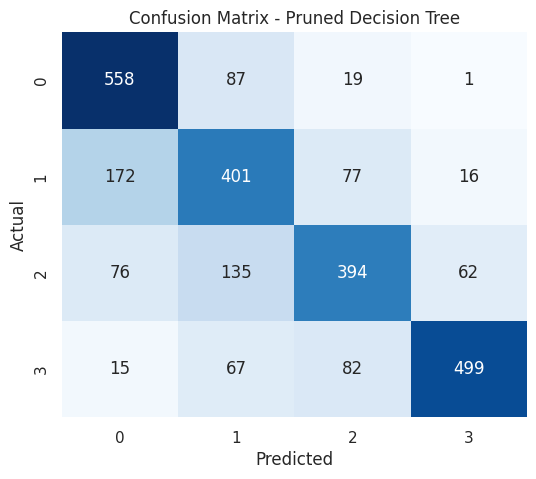

In [72]:
# Prediction
y_pred_pruned = best_model_pruned.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred_pruned)
report = classification_report(y_test, y_pred_pruned, output_dict=True)
cm = confusion_matrix(y_test, y_pred_pruned)

# result
print("Accuracy:", acc)
print("Precision:", report['weighted avg']['precision'])
print("Recall:", report['weighted avg']['recall'])
print("F1-score:", report['weighted avg']['f1-score'])
print("Confusion Matrix:\n", cm)


# Prediction
y_pred_pruned = best_model_pruned.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pruned)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Pruned Decision Tree')
plt.show()

**table to copmarison accuracy between splits**

In [73]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

results_classification = []

# best models result
best_models = [
    ("GridSearch Base", best_model1, X_test, y_test),
    ("Split Comparison", best_model_final, X_test_best, y_test_best),
    ("Pruning", best_model_pruned, X_test, y_test)
]

for name, model, X_t, y_t in best_models:
    y_pred = model.predict(X_t)
    report = classification_report(y_t, y_pred, output_dict=True)
    results_classification.append({
        "Experiment": name,
        "Accuracy": accuracy_score(y_t, y_pred),
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-score": report['weighted avg']['f1-score']
    })

results_classification = pd.DataFrame(results_classification)
print(results_classification)

         Experiment  Accuracy  Precision    Recall  F1-score
0   GridSearch Base  0.695227   0.699267  0.695227  0.695143
1  Split Comparison  0.695227   0.699267  0.695227  0.695143
2           Pruning  0.695979   0.703061  0.695979  0.695495


All are close to each other but the higher one  is purning

**Regression Task**

In [74]:
X_reg = df_dc.drop(['broad jump_cm','weight_kg','height_cm','systolic','diastolic','class'], axis=1)
y_reg = df_dc['broad jump_cm']


=== Regression ===

--- Train/Test Split: 80:20
MSE: 357.708
RMSE: 18.913
R2: 0.773


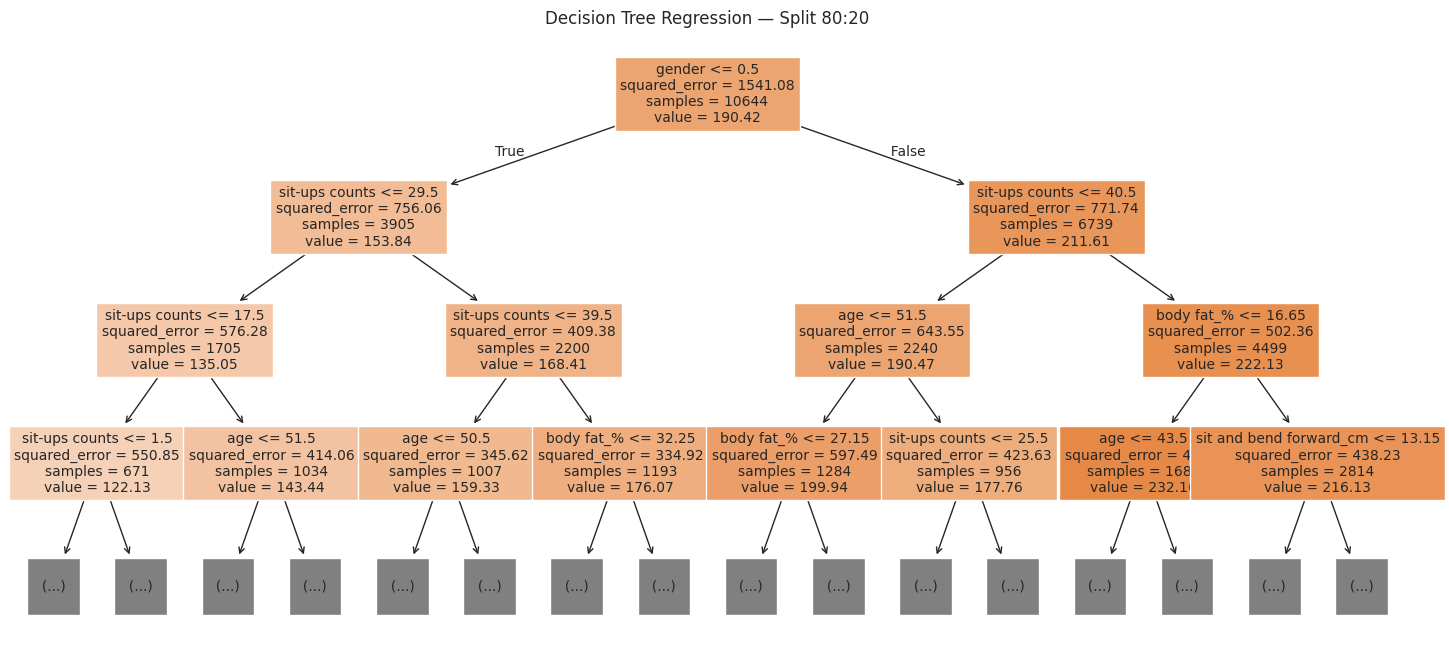


--- Train/Test Split: 70:30
MSE: 371.416
RMSE: 19.272
R2: 0.763


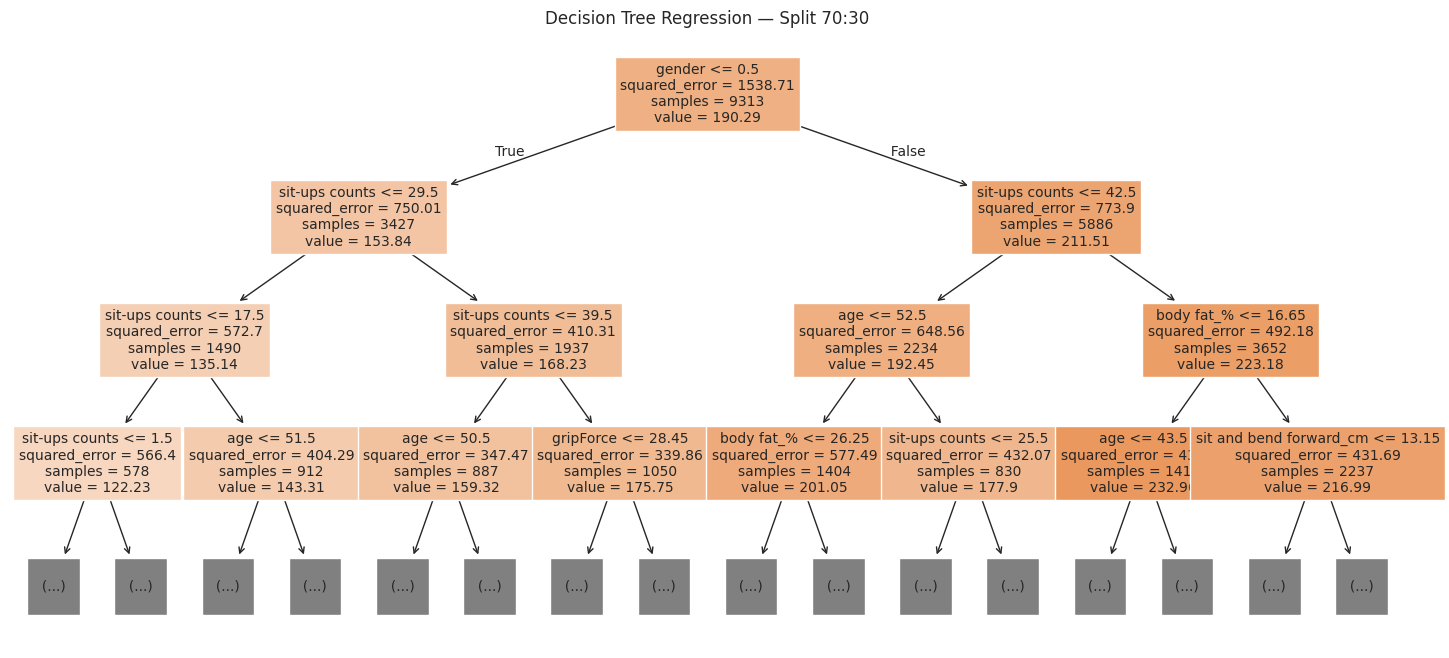


--- Train/Test Split: 50:50
MSE: 371.819
RMSE: 19.283
R2: 0.76


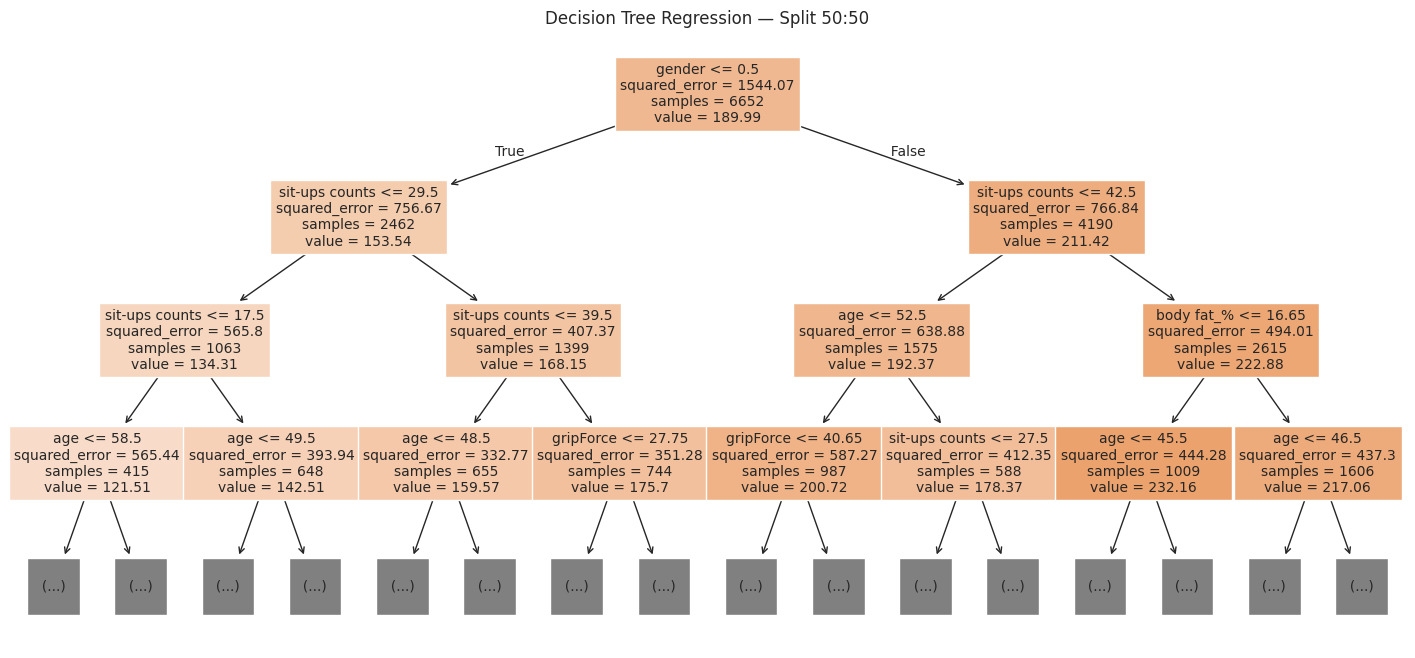

In [75]:
# Regression
print("\n=== Regression ===")
splits = [0.2, 0.3, 0.5]

for i in splits:
    print(f"\n--- Train/Test Split: {int((1-i)*100)}:{int(i*100)}")

    # Split the regression data
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg,
        test_size=i,
        random_state=42
    )

    # Initialize and fit the regressor
    reg = DecisionTreeRegressor(max_depth=7, random_state=42)
    reg.fit(X_train, y_train)

    # Make predictions
    y_pred = reg.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", round(mse, 3))
    print("RMSE:", round(rmse, 3))
    print("R2:", round(r2, 3))

    # Plot the tree
    plt.figure(figsize=(18, 8))
    # Using X_reg.columns directly avoids the IndexError
    plot_tree(reg,max_depth=3,
              feature_names=X_reg.columns.tolist(),
              filled=True,
              fontsize=10,
              precision=2)

    plt.title(f"Decision Tree Regression — Split {int((1-i)*100)}:{int(i*100)}")
    plt.show()

**Feature Importance**

Top features:
gender            0.626296
sit-ups counts    0.240838
age               0.052041
body fat_%        0.033964
gripForce         0.028294
dtype: float64


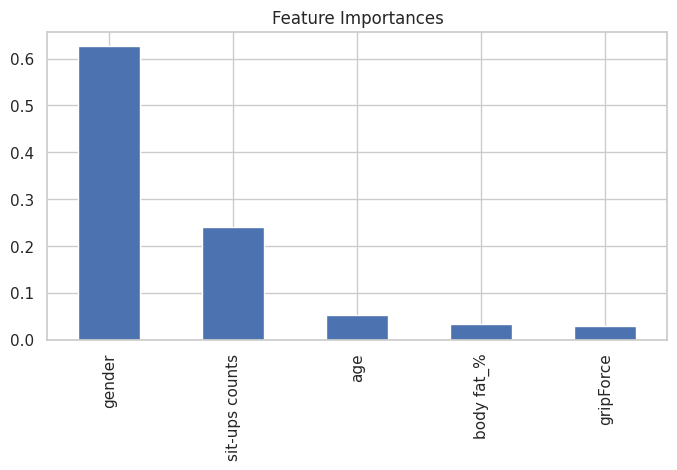

In [76]:
feature_names = X_reg.columns

fi = pd.Series(
    reg.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top features:")
print(fi.head(5))

fi.head(5).plot(kind="bar", figsize=(8,4), title="Feature Importances")

plt.show()

**K-Fold purning**




Best ccp_alpha: 0.5431735055155098
MSE: 361.835
RMSE: 19.022
R2: 0.7704


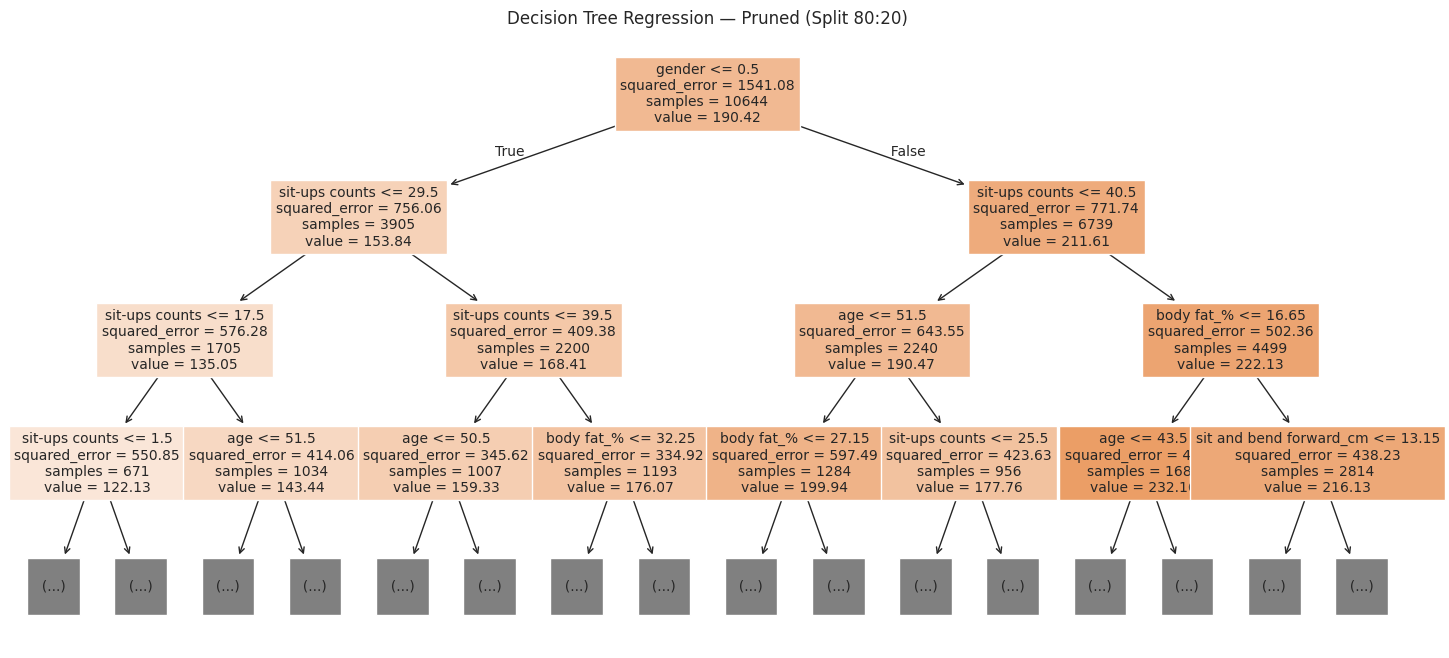

In [77]:
# 1. Split 80:20
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# =========================
# 2. Base Regressor
# =========================
base_reg = DecisionTreeRegressor(max_depth=12, random_state=42)  #best max_depth
path = base_reg.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[::5]

# =========================
# 3. GridSearchCV ccp_alpha
# =========================
# Regression KFold
from sklearn.model_selection import KFold

grid = GridSearchCV(
    DecisionTreeRegressor(max_depth=12, random_state=42),
    param_grid={'ccp_alpha': ccp_alphas},
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_reg = grid.best_estimator_


y_pred = best_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best ccp_alpha:", grid.best_params_['ccp_alpha'])
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2:", round(r2, 4))

# =========================
# tree
# =========================
plt.figure(figsize=(18, 8))
plot_tree(best_reg,
          max_depth=3,
          feature_names=X_reg.columns.tolist(),
          filled=True,
          fontsize=10,
          precision=2)
plt.title(f"Decision Tree Regression — Pruned (Split 80:20)")
plt.show()

**table to copmarison accuracy between splits**

In [78]:
results_regression = []

splits = [0.2, 0.3, 0.5]

for i in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg, test_size=i, random_state=42
    )

    reg = DecisionTreeRegressor(max_depth=7)
    reg.fit(X_train, y_train)

    y_pred = reg.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results_regression.append({
        "Model": "Decision Tree",
        "Split": f"{int((1-i)*100)}:{int(i*100)}",
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

results_regression = pd.DataFrame(results_regression)

print(results_regression)

           Model  Split         MSE       RMSE        R2
0  Decision Tree  80:20  357.707633  18.913160  0.772984
1  Decision Tree  70:30  371.415521  19.272144  0.763350
2  Decision Tree  50:50  372.971787  19.312478  0.759607


best split is 20:80
